<a href="https://colab.research.google.com/github/daniellerms/Analise-de-Dados-e-Boas-Praticas/blob/main/MVP_Analise_de_Dados_e_Boas_Praticas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MVP Análise de Dados e Boas Práticas

**Nome:** Danielle Rocha Macedo da Silva

**Matrícula:** 4052025001724


**Dataset:** [ITBI - Transações Imobiliárias por Divisão Administrativa e Ano - Imóveis Residenciais e Não Residenciais](https://github.com/daniellerms/Analise-de-Dados-e-Boas-Praticas/raw/refs/heads/main/ITBI%20-%20Transa%C3%A7%C3%B5es%20por%20Logradouro%20e%20M%C3%AAs%20-%20Im%C3%B3veis%20Residenciais%20e%20N%C3%A3o%20Residenciais.csv)

**Resumo do dataset:** Dados de transações imobiliárias da Cidade do Rio de Janeiro. Contém a informação sobre a compra e venda de imóveis Residenciais e Não Residenciais.

**Origem do dataset:** [DATA RIO](https://www.data.rio/datasets/PCRJ::itbi-transa%C3%A7%C3%B5es-por-logradouro-e-m%C3%AAs-im%C3%B3veis-residenciais-e-n%C3%A3o-residenciais/explore) - base de dados oficial da Prefeitura da Cidade do Rio de Janeiro

# Descrição do Problema

O conjunto de dados de **Transações Imobiliárias** possui informações sobre o Logradouro segundo a Natureza de Compra e Venda e de Promessa e Compra e Venda a partir de 2011.

O foco dessa análise será nos imóveis do tipo residencial, para isso será excluídos os imóveis 'Não Residenciais' da análise.

O objetivo principal desta análise é preparar os dados para realizar um modelo de regressão que permite inferir um valor médio de compra e venda para um imovel com base no bairro , tipo de imóvel e metragem.

## Hipóteses do Problema

As hipóteses que tracei são as seguintes:

1. **Bairros com maior volume de transações aumentam o valor médio da transação no ano seguinte?**
2. **Em quais bairrros há maior discrepância entre o valor médio da trasação e o valor médio do imóvel?**
3. **A sazonalidade afeta o volume de vendas na cidade de uma maneira geral?**
4. **Há diferença entre o preço do metro quadrado entre imóveis de tipologias diferentes?**


## Tipo de Problema

Este é um problema de **regressão supervisionada**. O Objetivo deste modelo é prever o valor de um imóvel com base no metro quadrado, tipo de imóvel e bairro.

## Seleção de Dados

O dataset escolhido é  **ITBI - Transações Imobiliárias por Divisão Administrativa e Ano - Imóveis Residenciais e Não Residenciais** que está disponível no DATARIO, base de dados oficial da cidade do Rio de Janeiro. O dataset foi escolhido devido a relevância dos dados para o Mercado Imobiliário e para a cidade do Rio de Janeiro e por percenter a um banco de dados oficial da cidade.

## Atributos do Dataset

O dataset Iris contém 95.584 linhas, com 16 atributos e são eles:

- **cl:** código do logradouro
- **logradouro:** nome do logradouro
- **codbairro:** código do bairro
- **bairro:** nome do bairro
- **total_transações:** quantidade de transações
- **uso:** tipo do uso, seja ele RESIDENCIAL ou NAO RESIDENCIAL
- **principais_tipologias:** tipologia do imovel, como "APARTAMENTO', 'CASA', 'GALPAO', LOJA SHOPPING', 'ARMAZEM/DEPOSITO', 'VAGA DE GARAGEM', 'GARAGEM/ESTACIONAMENTO', 'APARTAMENTO (PROLETARIO)'
- **média_percentual_transferido:** percentual médio do imovel que foi transferido na transação
- **média_área_construída:** metragem média do imóvel
- **média_valor_transação:** valor realizado na venda do imóvel
- **média_valor_imóvel:** valor médio do imóvel com base nos registros da prefeitura (valor venal do imóvel)
- **principal_transação_mercado:** informa em qual estagio jurídico da transação imobiliária foi realizado o pagamento do ITBI, seja na "COMPRA E VENDA" ou na "PROMESSA DE COMPRA E VENDA"
- **ano_transação:** ano em que a transação foi realizada
- **cd_utilizacao:** códido referente ao uso (RESIDENCIAL ou NAO RESIDENCIAL)
- **mês_transação:** mês da transação

# Importação das Bibliotecas Necessárias e Carga de Dados

Esta seção consolida todas as importações de bibliotecas necessárias para a análise, visualização e pré-processamento dos dados, bem como o carregamento inicial do dataset Iris.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.ticker import ScalarFormatter
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder
from sklearn.decomposition import PCA
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [2]:
# carregamento do dataset
url = r'https://github.com/daniellerms/Analise-de-Dados-e-Boas-Praticas/raw/refs/heads/main/ITBI%20-%20Transa%C3%A7%C3%B5es%20por%20Logradouro%20e%20M%C3%AAs%20-%20Im%C3%B3veis%20Residenciais%20e%20N%C3%A3o%20Residenciais.csv'


In [3]:
# guardo o dataset em um dataframe
df_completo = pd.read_csv(url)

In [4]:
# primeiras linhas errors='ignore
df_completo.head()

,objectid,cl,logradouro,codbairro,bairro,total_transações,uso,principais_tipologias,média_percentual_transferido,média_área_construída,média_valor_transação,média_valor_imóvel,principal_transação_mercado,ano_transação,cd_utilizacao,mês_transação
0,14618238,63867,RUA SACADURA CABRAL,1,Saúde,3,NAO RESIDENCIAL,SALA,100.0,36.333333,44728.496666,44728.496666,COMPRA E VENDA,2011,2,7
1,14618239,63966,AVN VENEZUELA,1,Saúde,3,NAO RESIDENCIAL,SALA,100.0,30.000000,33001.973333,33001.973333,COMPRA E VENDA,2011,2,2
2,14618240,63966,AVN VENEZUELA,1,Saúde,3,NAO RESIDENCIAL,SALA,100.0,86.333333,90339.566666,90339.566666,COMPRA E VENDA,2011,2,8
3,14618241,7690,RUA ANFILOFIO DE CARVALHO,5,Centro,5,NAO RESIDENCIAL,SALA,100.0,60.600000,92628.778000,92628.778000,COMPRA E VENDA,2011,2,5
4,14618242,60004,RUA ACRE,5,Centro,2,NAO RESIDENCIAL,SALA,100.0,25.000000,35273.920000,35273.920000,COMPRA E VENDA,2011,2,4


# Análise de Dados



## Total e Tipo das Instâncias

O dataset Iris possui 95584 instâncias.
Os Atributos categóricos (object): logradouro, bairro, uso, principais_tipologias, principal_transação_mercado.

Atributos numéricos reais (float64): média_percentual_transferido, média_área_construída, média_valor_transação, média_valor_imóvel.

Atributos numéricos inteiros (int64): objectid, cl, codbairro, total_transações, ano_transação, cd_utilizacao.

In [5]:
print(f"Total de instâncias: {len(df_completo)}")
print("\nTipos de dados por coluna:")
print(df_completo.info())

Total de instâncias: 95584

Tipos de dados por coluna:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 95584 entries, 0 to 95583
Data columns (total 16 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   objectid                      95584 non-null  int64  
 1   cl                            95584 non-null  int64  
 2   logradouro                    95584 non-null  object 
 3   codbairro                     95584 non-null  int64  
 4   bairro                        95584 non-null  object 
 5   total_transações              95584 non-null  int64  
 6   uso                           95584 non-null  object 
 7   principais_tipologias         95584 non-null  object 
 8   média_percentual_transferido  95584 non-null  float64
 9   média_área_construída         95584 non-null  float64
 10  média_valor_transação         95584 non-null  float64
 11  média_valor_imóvel            95580 non-null  float64
 12  princ

In [6]:
#separando as instâncias por tipos:
col_categoricas = ['logradouro', 'bairro', 'uso', 'principais_tipologias']

In [7]:
#removendo espaço das colunas categóricas
for coluna in col_categoricas:
  df_completo[coluna] = df_completo [coluna] .str.strip()

In [8]:
#acrescentando a coluna preco_m2_mercado e preco_m2_avaliado , que será necessária para as futuras análises
# Criando a coluna de Valor Total (100%)
df_completo['valor_total_mercado'] = df_completo['média_valor_transação'] / (df_completo['média_percentual_transferido'] / 100)

# Criando a coluna de Preço por Metro Quadrado Real
df_completo['preco_m2_mercado'] = df_completo['valor_total_mercado'] / df_completo['média_área_construída']


#Criando a coluna preco_m2_avaliado
df_completo['preco_m2_avaliado'] = df_completo['média_valor_imóvel']



In [9]:
#verificando as colunas do dataset
df_completo.columns

Index(['objectid', 'cl', 'logradouro', 'codbairro', 'bairro',
       'total_transações', 'uso', 'principais_tipologias',
       'média_percentual_transferido', 'média_área_construída',
       'média_valor_transação', 'média_valor_imóvel',
       'principal_transação_mercado', 'ano_transação', 'cd_utilizacao',
       'mês_transação', 'valor_total_mercado', 'preco_m2_mercado',
       'preco_m2_avaliado'],
      dtype='object')

In [10]:
#removendo as colunas que não serão usadas para facilitar a manipulação dos dados
df_completo = df_completo.drop(columns = ['objectid', 'cl','codbairro','cd_utilizacao' ])

In [11]:
#filtrando o dataset para trazer apenas o imoveis residenciais, que será o foco da análise deste trabalho
df_residencial = df_completo[df_completo ['uso'] == 'RESIDENCIAL'].copy()



In [12]:
df_residencial

,logradouro,bairro,total_transações,uso,principais_tipologias,média_percentual_transferido,média_área_construída,média_valor_transação,média_valor_imóvel,principal_transação_mercado,ano_transação,mês_transação,valor_total_mercado,preco_m2_mercado,preco_m2_avaliado
11779,LAD BARROSO,Gamboa,2,RESIDENCIAL,CASA,100.0,127.000000,1.032284e+05,1.032284e+05,COMPRA E VENDA,2011,7,1.032284e+05,812.822323,1.032284e+05
11780,RUA NABUCO DE FREITAS,Santo Cristo,2,RESIDENCIAL,CASA,100.0,50.500000,2.424340e+04,2.424340e+04,COMPRA E VENDA,2011,3,2.424340e+04,480.067228,2.424340e+04
11781,RUA ANDRE CAVALCANTI,Centro,2,RESIDENCIAL,APARTAMENTO,100.0,38.500000,9.802984e+04,9.802984e+04,COMPRA E VENDA,2011,1,9.802984e+04,2546.229481,9.802984e+04
11782,RUA CARLOS DE CARVALHO,Centro,2,RESIDENCIAL,APARTAMENTO,100.0,49.500000,2.236051e+05,2.236051e+05,COMPRA E VENDA,2011,11,2.236051e+05,4517.275657,2.236051e+05
11783,RUA EVARISTO DA VEIGA,Centro,2,RESIDENCIAL,APARTAMENTO,100.0,34.000000,1.289039e+05,1.289039e+05,COMPRA E VENDA,2011,10,1.289039e+05,3791.291765,1.289039e+05
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95579,RUA ALFREDO CESCHIATTI,Barra Olímpica,2,RESIDENCIAL,APARTAMENTO,83.5,73.500000,5.021950e+05,6.022406e+05,COMPRA E VENDA,2026,2,6.014311e+05,8182.735834,6.022406e+05
95580,RUA 3 PAA 11932,Barra Olímpica,5,RESIDENCIAL,APARTAMENTO,100.0,84.800000,4.796176e+05,4.796176e+05,COMPRA E VENDA,2026,2,4.796176e+05,5655.867948,4.796176e+05
95581,RUA RODRIGO MELO FRANCO (ESCRITOR),Barra Olímpica,11,RESIDENCIAL,APARTAMENTO,100.0,119.272727,1.009577e+06,1.009577e+06,COMPRA E VENDA,2026,1,1.009577e+06,8464.443724,1.009577e+06
95582,AVN VICE PRESIDENTE JOSE ALENCAR,Barra Olímpica,9,RESIDENCIAL,APARTAMENTO,100.0,115.000000,1.074090e+06,1.074090e+06,COMPRA E VENDA,2026,2,1.074090e+06,9339.916647,1.074090e+06


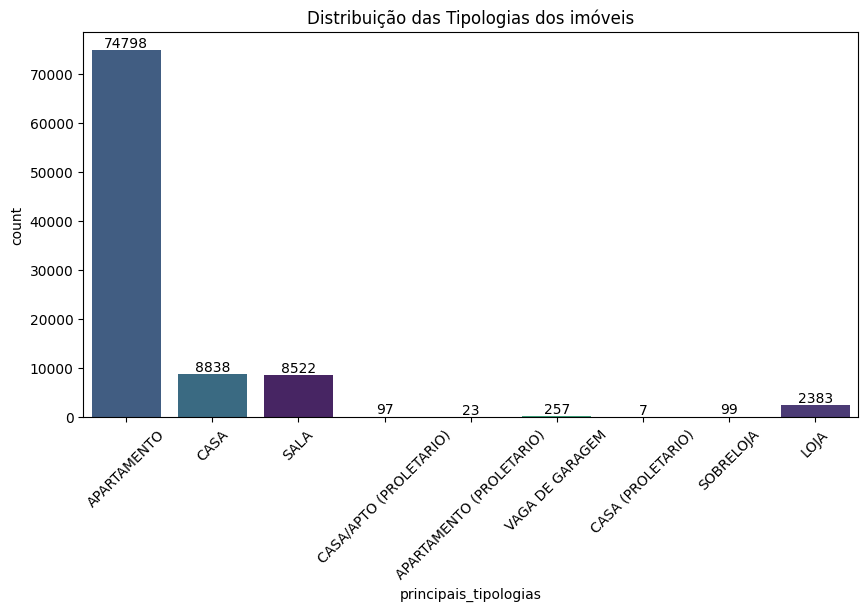

In [13]:
plt.figure(figsize=(10, 5))
# gráfico de barras simples
ax = sns.countplot(x='principais_tipologias', data=df_completo, palette='viridis', order=df_residencial['principais_tipologias'].value_counts().index, hue='principais_tipologias', legend=False)
plt.title('Distribuição das Tipologias dos imóveis')
plt.xticks(rotation=45)

# Adicionar rótulos de dados
for container in ax.containers:
    ax.bar_label(container, fmt='%.0f')

plt.show()

O gráfico de barras acima nos mostra que esse dataset não é balanceado em termo de tipologia de imóveis e foi feita com base na contagem de registros, pois isso representa a quantidade de amostras disponíveis para o treinamento do modelo. Assim, é possível observar que quantidade da tipologia "apartamentos" é muito superior comparado as demais e o modelo se torna mais preciso para essa tipologia.

Para realizar uma análise mais focada, irei optar por restringir essa análise apenas imóveis residenciais.

In [14]:
print(f"Total de instâncias: {len(df_residencial)}")
print("\nTipos de dados por coluna:")
print(df_residencial.info())

Total de instâncias: 83682

Tipos de dados por coluna:
<class 'pandas.core.frame.DataFrame'>
Index: 83682 entries, 11779 to 95583
Data columns (total 15 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   logradouro                    83682 non-null  object 
 1   bairro                        83682 non-null  object 
 2   total_transações              83682 non-null  int64  
 3   uso                           83682 non-null  object 
 4   principais_tipologias         83682 non-null  object 
 5   média_percentual_transferido  83682 non-null  float64
 6   média_área_construída         83682 non-null  float64
 7   média_valor_transação         83682 non-null  float64
 8   média_valor_imóvel            83680 non-null  float64
 9   principal_transação_mercado   83682 non-null  object 
 10  ano_transação                 83682 non-null  int64  
 11  mês_transação                 83682 non-null  int64  
 12  valor_

O dataset filtrado possui agora 83682 instâncias

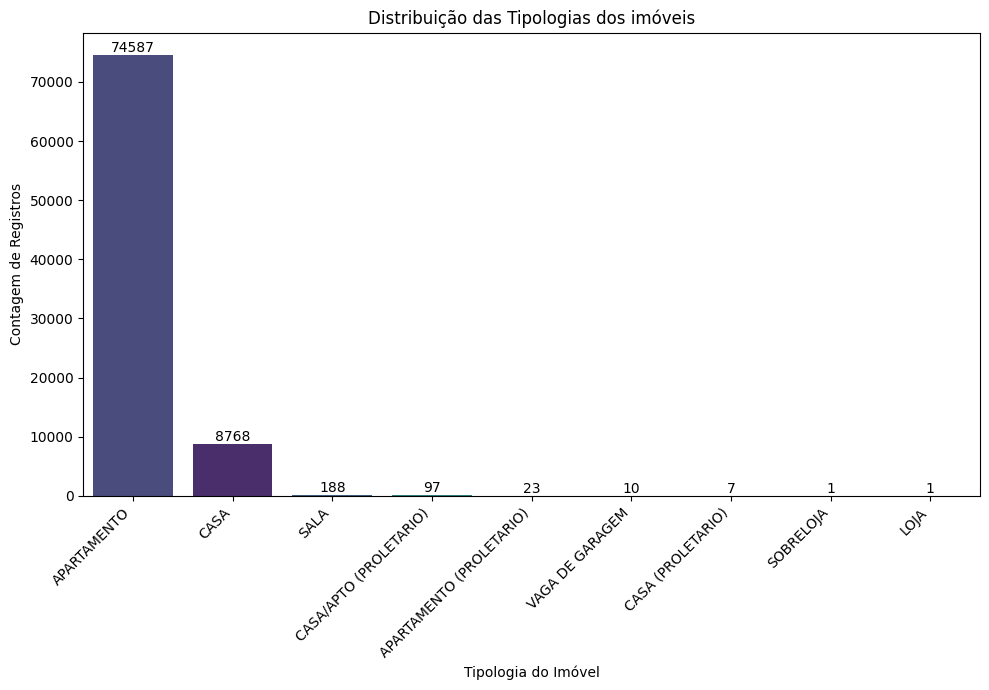

In [15]:
#Refazendo a distribuição agora com os dados filtrados

plt.figure(figsize=(10, 7))
# gráfico de barras simples
ax = sns.countplot(x='principais_tipologias', data=df_residencial, palette='viridis', order=df_residencial['principais_tipologias'].value_counts().index, hue='principais_tipologias', legend=False)
plt.title('Distribuição das Tipologias dos imóveis')
plt.xlabel('Tipologia do Imóvel')
plt.ylabel('Contagem de Registros')
plt.xticks(rotation=45, ha='right')

# Adicionar rótulos de dados
for container in ax.containers:
    ax.bar_label(container, fmt='%.0f')

plt.tight_layout()
plt.show()

Como esperado, o dataset continua desbalanceado. Sendo, apartamento o que possui mais registros. No entanto, ainda aparecem tipologias que parecem ser referentes a imóveis não residenciais que seram tratados na etapa de pré-processamento.

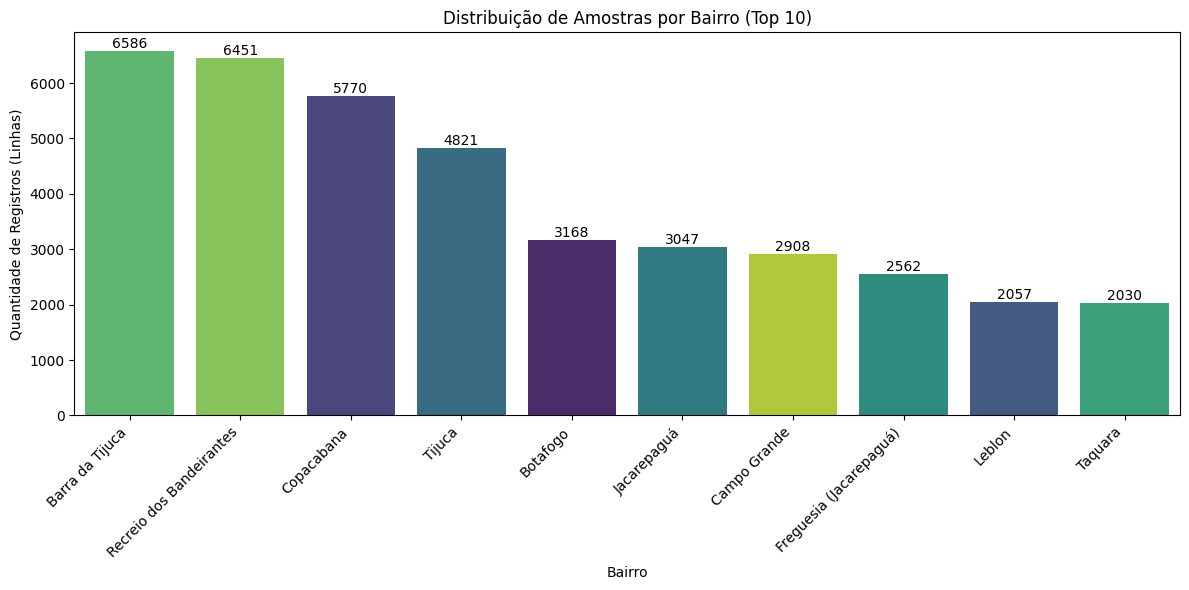

In [16]:
plt.figure(figsize=(12, 6))
# Obter os top 10 bairros
top_10_bairros = df_residencial['bairro'].value_counts().nlargest(10).index

# Filtrar o DataFrame para incluir apenas os top 10 bairros
df_top_10_bairros = df_residencial[df_residencial['bairro'].isin(top_10_bairros)]

# Criar o gráfico de barras apenas para os top 10 bairros
ax = sns.countplot(x='bairro', data=df_top_10_bairros, order=top_10_bairros, palette='viridis', hue='bairro', legend=False)
plt.title('Distribuição de Amostras por Bairro (Top 10)')
plt.xlabel('Bairro')
plt.ylabel('Quantidade de Registros (Linhas)')
plt.xticks(rotation=45, ha='right') # rótulos rotacionados para melhor leitura

# Adicionar rótulos de dados
for container in ax.containers:
    ax.bar_label(container, fmt='%.0f')

plt.tight_layout()
plt.show()

Ao analisar a quantidade de amostras por bairros vemos que tem uma boa diferença na quantidade de registros de transação, comparando o primeiro com o último do top 10. Essa concentração indica que o modelo terá uma base de aprendizado mais robusta para as localidades com maior número de transações, o que favorece a precisão nessas regiões.

/tmp/ipykernel_3820/46538001.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df_residencial, x='ano_transação', palette='viridis')


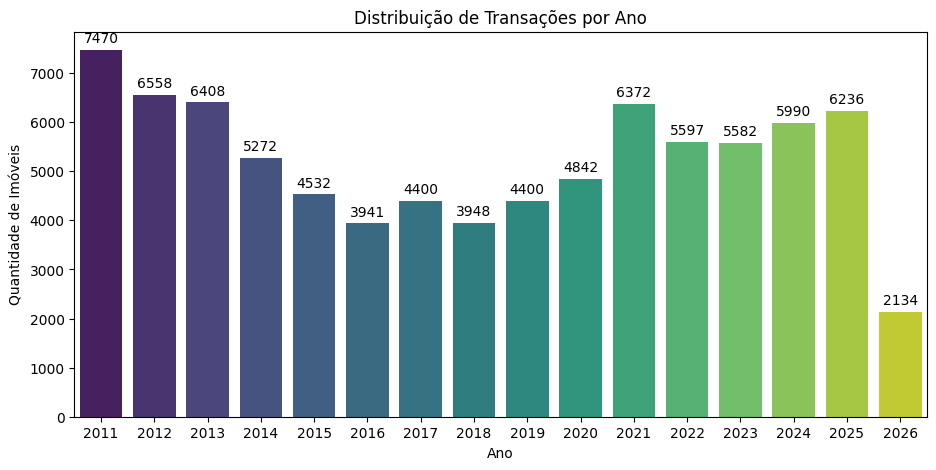

In [17]:
#verificando a distribuição dos dados por ano
plt.figure(figsize=(11, 5))

# Gráfico de barras com a contagem anual
ax = sns.countplot(data=df_residencial, x='ano_transação', palette='viridis')

# Adicionando os números em cima das barras para facilitar a leitura
for i in ax.containers:
    ax.bar_label(i, padding=3)

plt.title('Distribuição de Transações por Ano')
plt.xlabel('Ano')
plt.ylabel('Quantidade de Imóveis')
plt.show()

Como podemos ver no gráfico, as transações são balanceadas com relação aos anos. Apesar dos dados estarem balanceados, um período de 15 anos questões como inflação vão interferir bastante na precisão do modelo para prever o valor médio de compra e venda para um imovel com base no bairro, rua e metragem.

Por isso, na etapa de pre-processamento, irei restrigir o dataset com os dados de 2019 a 2026, pois é um período no qual a inflação interfere, no qual é mais viável comparar os valores do imóvel ao longo dos anos. Assim é possível analisar o período pré, durante e pós-pandemia. Além disso, esse intervalo de tempo permite responder as perguntas elaboradas na hipótese relacionadas a análises temporais, como a sazonalidade, por exemplo.

## Estatísticas Descritivas

Estatísticas descritivas fornecem um resumo das características numéricas, incluindo média, desvio padrão, mínimo, máximo e quartis.

In [18]:
# estatísticas descritivas básicas do dataset
with pd.option_context("float_format", "{:,.2f}".format):
    display(df_residencial.describe())

,total_transações,média_percentual_transferido,média_área_construída,média_valor_transação,média_valor_imóvel,ano_transação,mês_transação,valor_total_mercado,preco_m2_mercado,preco_m2_avaliado
count,"83,682.00","83,682.00","83,682.00","83,682.00","83,680.00","83,682.00","83,682.00","83,682.00","83,682.00","83,680.00"
mean,4.26,96.49,99.41,"639,810.87","730,231.37","2,018.11",6.55,inf,inf,"730,231.37"
std,5.91,11.49,233.41,"843,361.71","5,163,217.49",4.73,3.42,NaN,NaN,"5,163,217.49"
min,2.00,0.00,1.00,3.29,3.29,"2,011.00",1.00,3.29,0.06,3.29
25%,2.00,100.00,60.50,"223,350.45","231,937.03","2,014.00",4.00,"231,678.43","3,496.45","231,937.03"
50%,3.00,100.00,77.08,"396,857.97","414,900.92","2,018.00",7.00,"413,640.28","5,248.88","414,900.92"
75%,4.00,100.00,103.33,"750,699.78","789,058.39","2,022.00",10.00,"785,663.01","8,594.37","789,058.39"
max,526.00,100.00,"17,220.00","27,094,922.36","933,333,300.00","2,026.00",12.00,inf,inf,"933,333,300.00"


Com báse nas estatísticas básicas do dataset podemos perceber ruídos nos dados. O primeiro ponto de atenção é a coluna "média_percentual_transferido", que mostra transações nulas, ou seja 0% do imóvel teria sido tranferido.

Outro ponto de destaque é a 'média_área_construída' com valor 1.00, esse valor não faz sentido para representar a área de um imóvel. Para ter um valor lógico, será definido como área mínima aceitável o valor de 15.00 m².

No mesmo sentido, a 'média_valor_transação' e a 'média_valor_imóvel' tem valores mínimos muito baixos, 3.28 e 3.29, respectivamente.

A a 'média_valor_transação' e a 'média_valor_imóvel' também possuem valores máximos bem altos.  Com isso, também é possível observar um desvio padrão de 6,4 milhões.

Por fim, como as colunas 'valor_total_mercado' e 'preco_m2_mercado' possui valores 'inf', uma vez que é calculada com base na divisão pela coluna 'média_percentual_transferido', que possui valores nulos. O tratamento de valores nulos será realizado na etapa de pré-processamento dos dados.

### Média


In [19]:
# média dos atributos numéricos do dataset
with pd.option_context("float_format", "{:,.2f}".format):
  display(df_residencial.describe().loc['mean'])

,mean
total_transações,4.26
média_percentual_transferido,96.49
média_área_construída,99.41
média_valor_transação,"639,810.87"
média_valor_imóvel,"730,231.37"
ano_transação,"2,018.11"
mês_transação,6.55
valor_total_mercado,inf
preco_m2_mercado,inf
preco_m2_avaliado,"730,231.37"


Ao observar a média, o primeiro ponto de atenção é que o média do valor de avaliação é maior do que a média do valor de transação
- média_valor_imóvel: 730,231.37 reais
- média_valor_transação: 639,810.87 reais


Já a média de tamanho do imóvel é 99.41m2 e a média de transferências é de 96,49%, ou seja, a maioria das transções é do total do imóvel e poucos são os casos de heranças, por exemplo.

Já com relação ao ano médio, 2018 mostra que o dataset está equilibrado em relação aos anos.

/tmp/ipykernel_3820/1300614098.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='bairro', y='média_valor_transação',


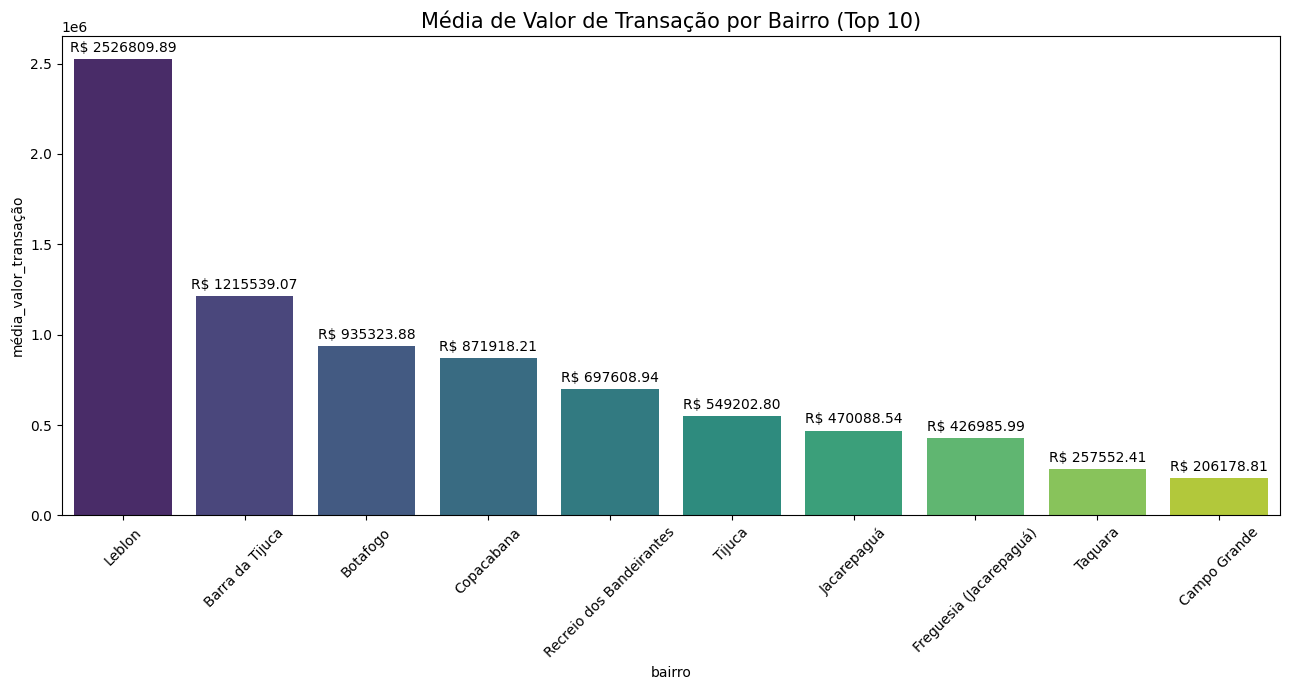

In [20]:
# @title Texto de título padrão
plt.figure(figsize=(13, 7))

# Obtendo os top 10 bairros
top_10_bairros = df_residencial['bairro'].value_counts().nlargest(10).index
df_top_10_bairros = df_residencial[df_residencial['bairro'].isin(top_10_bairros)]

# ordenando por média do valor da transação
mean_values_ordered = df_top_10_bairros.groupby('bairro')['média_valor_transação'].mean().sort_values(ascending=False).index

# Criando o gráfico de barras com a ordem desejada
ax = sns.barplot(x='bairro', y='média_valor_transação',
                 data=df_top_10_bairros, estimator='mean', errorbar=None, palette='viridis', order=mean_values_ordered)

# Adicionando os rótulos em cima de cada barra
for i in ax.containers:
    ax.bar_label(i, fmt='R$ %.2f', padding=3, fontsize=10)

plt.title('Média de Valor de Transação por Bairro (Top 10)', fontsize=15)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Desvio Padrão



In [21]:
# desvio padrão dos atributos numéricos do dataset
with pd.option_context("float_format", "{:.2f}".format):
  display(df_residencial.describe().loc['std'])

,std
total_transações,5.91
média_percentual_transferido,11.49
média_área_construída,233.41
média_valor_transação,843361.71
média_valor_imóvel,5163217.49
ano_transação,4.73
mês_transação,3.42
valor_total_mercado,NaN
preco_m2_mercado,NaN
preco_m2_avaliado,5163217.49


Ao analisar a tabela de desvios-padrão, os principais destaques são os valores nulos (NaN) no preço do m² e no valor total de mercado. Isso ocorre devido à presença de valores zero nas colunas de área, gerando divisões indeterminadas que serão tratadas no pré-processamento.

Além disso, observa-se que o desvio-padrão da média do valor de transação é de **84.336,71**, enquanto o da média do valor do imóvel atinge **5.163.217,49**. Esses números reforçam que os dados originais são extremos, com uma forte presença de outliers que distorcem a realidade estatística.

Para diminuir a dispersão e aumentar a precisão da análise, durtante o pré-processamento, irei restrigir o dataset a imóveis residenciais (casa e apartamento) com área entre **15m²** **100m²** e valor médio de transação de até **R$ 1,5 milhão**.

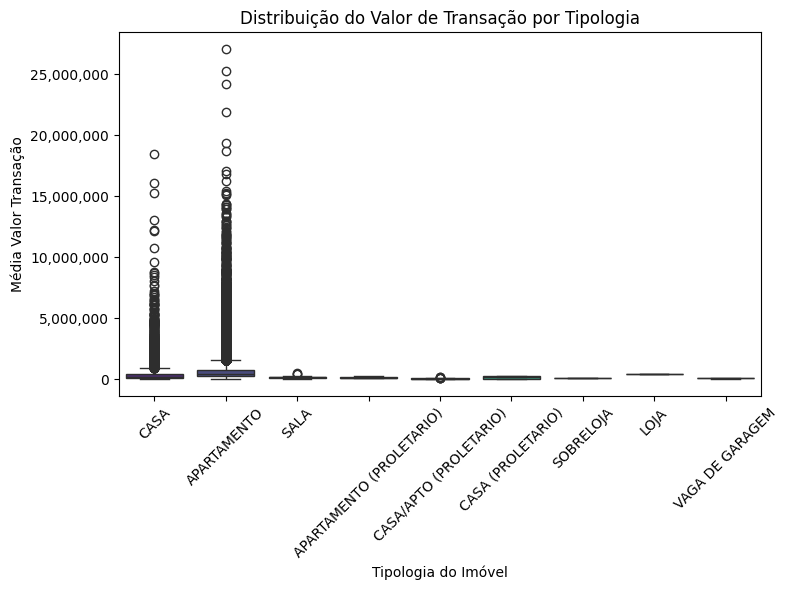

In [22]:
plt.figure(figsize=(8, 6))

# Boxplot da Média do Valor de Transação por Tipologias
sns.boxplot(x='principais_tipologias', y='média_valor_transação', data=df_residencial, palette='viridis', hue='principais_tipologias', legend=False)
plt.gca().yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: '{:,.0f}'.format(x))) # formatando o os numeros
plt.title("Distribuição do Valor de Transação por Tipologia")
plt.xticks(rotation=45)
plt.xlabel('Tipologia do Imóvel')
plt.ylabel('Média Valor Transação')

plt.tight_layout()
plt.show()

No boxplot, que relaciona a média do valor da transação por tipologia do imível, é possivel observar uma grande dispersão nos dados. Com uma grande quantidade de outliers além do terceiro quartil. Essa distorção impossibilita a leitura do intervalo interquartis e da mediana, o que reforça os pontos levantados anteriormente de que é necessário filtrar o dataset para um uma amostra mais limitada para melhorar a precisão dos dados. E que a média não é uma medida de tendência central para este dataset, sem a devida limpesa dos dados.



/tmp/ipykernel_3820/1847521052.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='principais_tipologias', y='média_área_construída', data=df_residencial, palette='viridis')


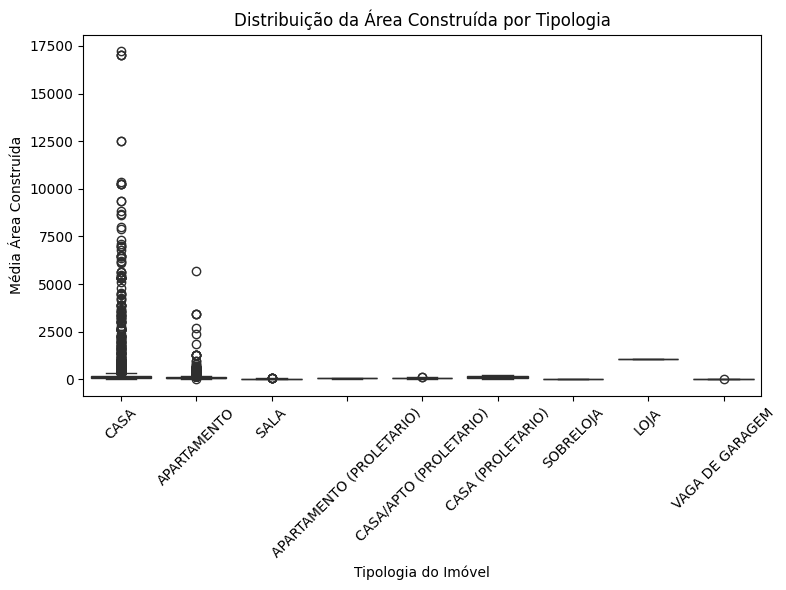

In [23]:
plt.figure(figsize=(8, 6))

# Boxplot da Média da Área Construída por Tipologias
sns.boxplot(x='principais_tipologias', y='média_área_construída', data=df_residencial, palette='viridis')
plt.title("Distribuição da Área Construída por Tipologia")
plt.tick_params(axis='x', rotation=45)
plt.xlabel('Tipologia do Imóvel')
plt.ylabel('Média Área Construída')



plt.tight_layout()
plt.show()

O boxplot, que relaciona a distribuição da area construida por tipologia do imóvel, tambéme é possivel observar uma grande dispersão nos dados. Com uma grande quantidade de outliers além do terceiro quartil. E novamente, essa distorção impossibilita a leitura do intervalo interquartis e da mediana , o que reforça os pontos levantados anteriormente de que é necessário filtrar o dataset para um uma amostra mais limitada para melhorar a precisão dos dados. E que a média não é uma medida de tendência central para este dataset, sem a devida limpesa dos dados.

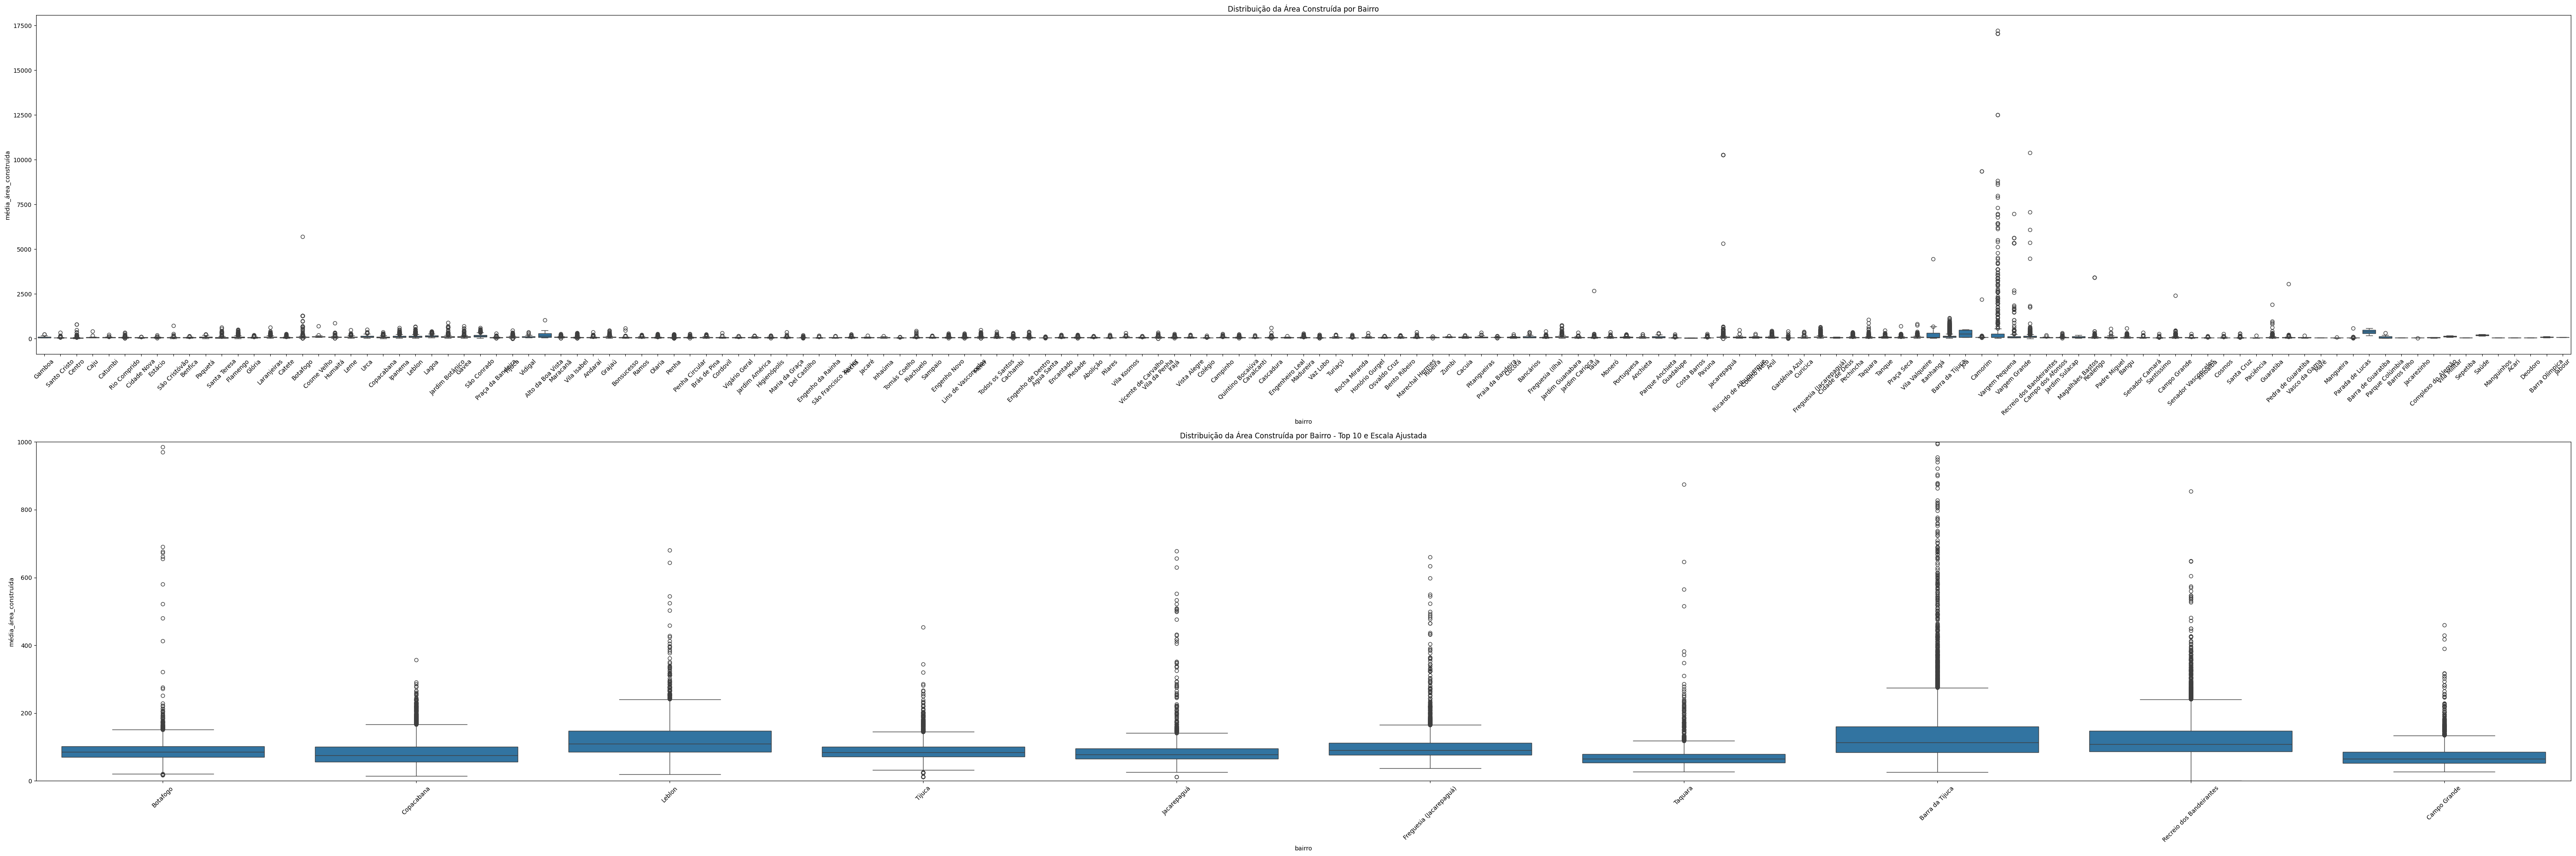

In [24]:
fig, ax = plt.subplots(2,1, figsize = (60,20))

#  Filtro para não poluir o gráfico
top_10_bairros = df_residencial['bairro'].value_counts().nlargest(10).index
df_plot = df_residencial[df_residencial['bairro'].isin(top_10_bairros)]

# subplot 1: Boxplot do Preço por M2 de Mercado por Tipologias
sns.boxplot(x='bairro', y='média_área_construída', data=df_residencial, ax=ax[0])
ax[0].set_title("Distribuição da Área Construída por Bairro")
ax[0].tick_params(axis='x', rotation=45)
ax[0].set_xlabel('bairro')
ax[0].set_ylabel('média_área_construída')


# subplot 2: Boxplot do Preço por M2 Avaliado por Tipologias
sns.boxplot(x='bairro', y='média_área_construída', data=df_plot, ax=ax[1])
ax[1].set_ylim(0, 1000) #ajustando a escala -> limitando o eixo y em 1000
ax[1].set_title("Distribuição da Área Construída por Bairro - Top 10 e Escala Ajustada")
ax[1].tick_params(axis='x', rotation=45)
ax[1].set_xlabel('bairro')
ax[1].set_ylabel('média_área_construída')

plt.tight_layout()
plt.show()

Ao analisar a área construída por bairro, o primeiro gráfico reforça a escala impraticável devido aos outliers. Por este motivo, optei por usar o segundo gráfico, com a escala ajustada e foco nos 10 bairros com maior volume, para tornar a visualização da variabilidade área construtiva entre as regiões. Assim, é possível notar que a grande maioria das transações está concentrada abaixo dos 200m², o que reforça a decisão estratégica de limitar a amostra a imóveis de até 100m² para aumentar a precisão do modelo preditivo.

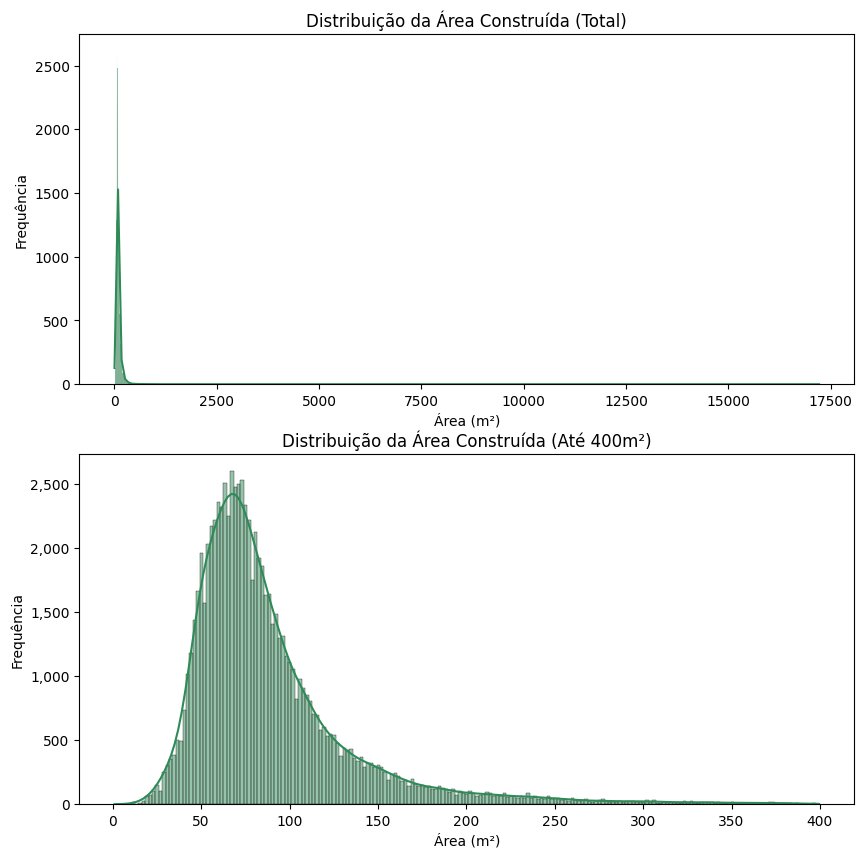

In [25]:
#criando histogramas para analisar a frequência dos registros com relação a área construída

fig, ax = plt.subplots(2,1,figsize=(10, 10))


#
sns.histplot(df_residencial['média_área_construída'], kde=True, color='seagreen', ax=ax[0])
plt.gca().yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: '{:,.0f}'.format(x))) # formatando o os numeros
ax[0].set_title('Distribuição da Área Construída (Total)')
ax[0].set_xlabel('Área (m²)')
ax[0].set_ylabel('Frequência')

# Limitando a área a 400m2 para evitar que o gráfico fique "esmagado" pelos outliers
sns.histplot(df_residencial[df_residencial['média_área_construída'] < 400]['média_área_construída'],
             kde=True, color='seagreen', ax=ax[1])
plt.gca().yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: '{:,.0f}'.format(x))) # formatando o os numeros
ax[1].set_title('Distribuição da Área Construída (Até 400m²)')
ax[1].set_xlabel('Área (m²)')
ax[1].set_ylabel('Frequência')


plt.show()

O histograma mostra a distribuição da área construída. Nele, podemos observar uma assimetria positiva, com uma cauda longa a direita. Isso indica que há imóveis com áreas muito grandes, mas são mais raros.

No segundo gráfico, ao limitar a visualização para até **400 m2**, conseguimos observar que a maior frequência dos registros, ou seja a **moda** ocorre entre **50m² e 80m²**. Além disso, a quantidade de registros com mais de 150m² cai drasticamente. Nesse cenário, a **média** simples, está enviesada pelo ruídos desse dataset.

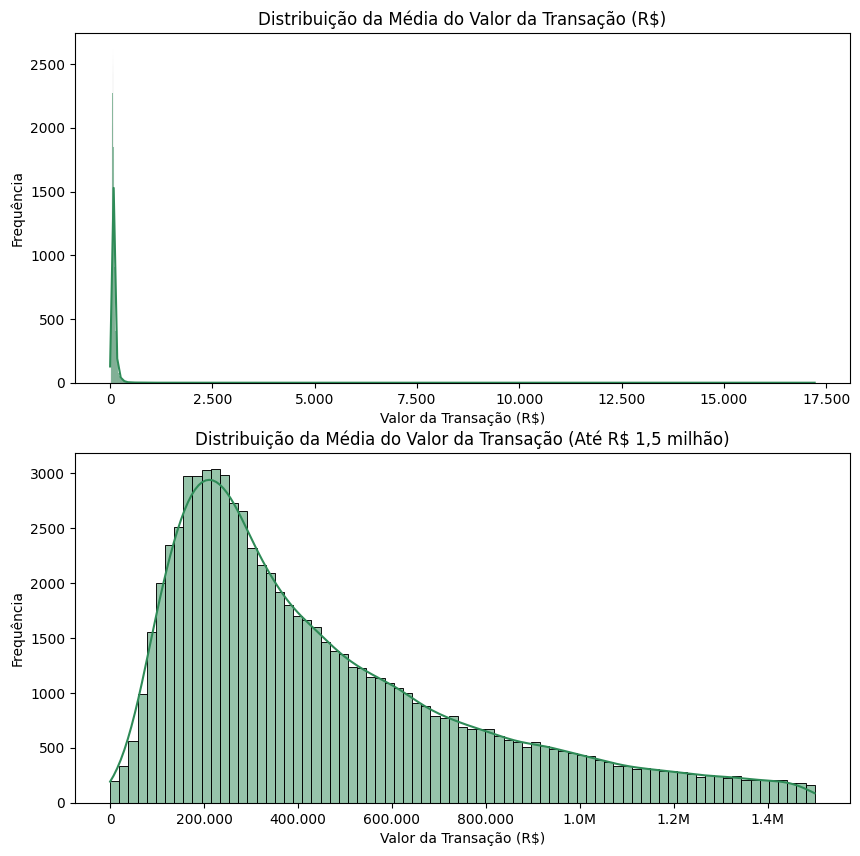

In [26]:

#criando histogramas para analisar a frequência dos registros com relação a Média do Valor da Transação

fig, ax = plt.subplots(2,1,figsize=(10, 10))



sns.histplot(df_residencial['média_área_construída'], kde=True, color='seagreen', ax=ax[0])
ax[0].set_title('Distribuição da Média do Valor da Transação (R$)')
ax[0].set_xlabel('Média do Valor da Transação')
ax[0].set_ylabel('Frequência')

# Limitando a área a 400m2 para evitar que o gráfico fique "esmagado" pelos outliers
sns.histplot(df_residencial[df_residencial['média_valor_transação'] < 1500000]['média_valor_transação'],
             kde=True, color='seagreen', ax=ax[1])
ax[1].set_title('Distribuição da Média do Valor da Transação (Até R$ 1,5 milhão)')
ax[1].set_xlabel('Média do Valor da Transação')
ax[1].set_ylabel('Frequência')

# Ajustando a escala de ambos os eixos X para formato de moeda
for a in ax:
    a.set_xlabel('Valor da Transação (R$)')
    a.set_ylabel('Frequência')
    # Formata os números do eixo X para milhar com ponto (Ex: 500.000)
    a.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{x/1e6:.1f}M' if x >= 1e6 else f'{x:,.0f}'.replace(',', '.')))

plt.show()


Como podemos observar no histograma dos valores médios da transação, temos novamente uma assimentria positiva, com outliers com grandes valores, porem pouco frequentes e que interferem na precisão da média como medida de tendência.

Ao filtrarmos o gráfico para valores médis de transação de até R$1,5 milhão, conseguimos observar que a moda entre em **200.000,00** reais e **300.000,00** reais. Observamos ainda, que o gráfico cai suavemente após ultrapassar **800.000,00** reais, a distribuição passa a reduzir de forma mais suave.

Quais impressões você tem sobre a distribuição do atributo 'sepal width'?

## Matriz de Correlação

A matriz de correlação mede a força e a direção de uma relação linear que os atributos numéricos das espécies podem ter. Valores próximos a 1 indicam uma forte correlação positiva, -1 uma forte correlação negativa, e 0 ausência de correlação linear.

In [27]:
# Matriz de correlação
print("\nMatriz de Correlação:")
matriz_correlacao = df_residencial.drop(columns = ['ano_transação','mês_transação','valor_total_mercado','preco_m2_mercado','média_percentual_transferido','preco_m2_avaliado']).corr(numeric_only=True)

display(matriz_correlacao)


Matriz de Correlação:


,total_transações,média_área_construída,média_valor_transação,média_valor_imóvel
total_transações,1.000000,-0.019168,-0.010755,-0.005652
média_área_construída,-0.019168,1.000000,0.139222,0.153879
média_valor_transação,-0.010755,0.139222,1.000000,0.161939
média_valor_imóvel,-0.005652,0.153879,0.161939,1.000000


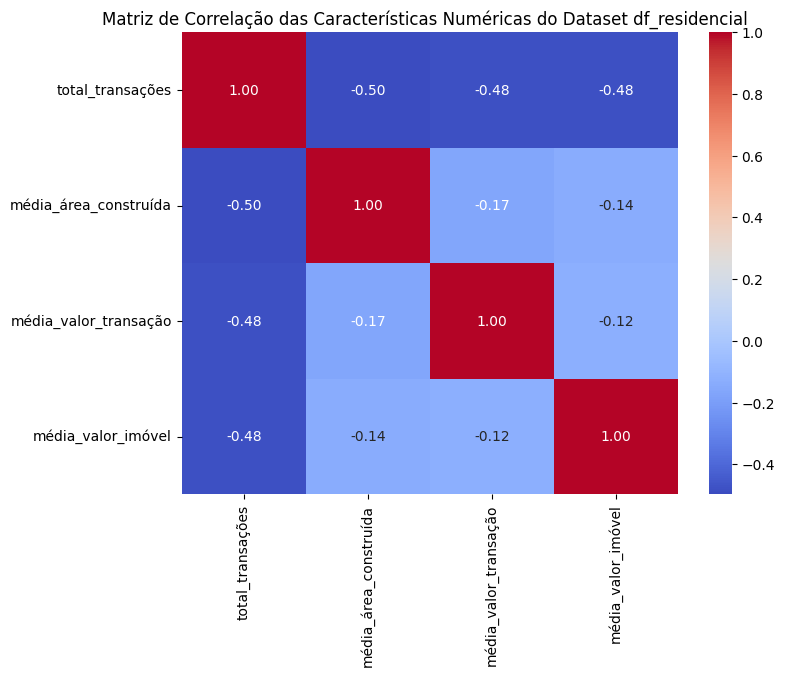

In [28]:
plt.figure(figsize=(8, 6))
# mapa de calor das variáveis numéricas
sns.heatmap(matriz_correlacao.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriz de Correlação das Características Numéricas do Dataset df_residencial  ')
plt.show()

A matriz de correlação mostra uma correlação fraca entre as variáveis númericas do dataset, sendo a maior correlação entre o total de transações e área, correlação **-0.50**, o que sugere que transações com imóveis de menor área média tendem a apresentar maior volume de vendas.

Outra correlação é entre o **valor médio de venda** e o **total de transações** (**-0.48**) o que indica que quanto maior o valor de venda, menor o número de transações no período.

No entanto essas correlações são sensíveis aos outliers, que ainda não foram tratados nesse dataset. Com isso, uma vez com os dados tratados poderemos entender melhor a relação entre as variáveis.

## Tratamento de Valores Nulos

O dataset Iris original não possui valores nulos. No entanto, o tratamento de valores nulos é crucial e pode envolver imputação (preenchimento com média, mediana, moda) ou remoção de linhas/colunas.

In [29]:
# Verificar a presença de valores nulos no dataset original
print("Valores nulos no dataset df_residencial:")
df_residencial.isnull().sum()

Valores nulos no dataset df_residencial:


,0
logradouro,0
bairro,0
total_transações,0
uso,0
principais_tipologias,0
média_percentual_transferido,0
média_área_construída,0
média_valor_transação,0
média_valor_imóvel,2
principal_transação_mercado,0


Podemos perceber a presença de valores nulos nas colunas de **'média_valor_imóvel'** e na **'preco_m2_avaliado'**. Como a segunda calculada com base na primeira, então ao tratar os nulos da **'média_valor_imóvel'** resolverei ambas as pendências.

No entanto, essa análise será revisada após a etapa de filtragem do dataset para confirmar se ainda há a presença de valores nulos ou se foram removidos junto com os outliers.

# Pré-Processamento de Dados


In [30]:
#como observado anteriormente há 'principais_tipologias' 'LOJA' dentro dos dados residenciais
df_residencial['principais_tipologias'].unique()

array(['CASA', 'APARTAMENTO', 'SALA', 'APARTAMENTO (PROLETARIO)',
       'CASA/APTO (PROLETARIO)', 'CASA (PROLETARIO)', 'SOBRELOJA', 'LOJA',
       'VAGA DE GARAGEM'], dtype=object)

In [31]:
df_residencial['principais_tipologias'].value_counts()


,count
principais_tipologias,
APARTAMENTO,74587
CASA,8768
SALA,188
CASA/APTO (PROLETARIO),97
APARTAMENTO (PROLETARIO),23
VAGA DE GARAGEM,10
CASA (PROLETARIO),7
SOBRELOJA,1
LOJA,1


VAGA DE GARAGEM, SOBRELOJA e LOJA são tipologias de imoveis residenciais e podem ter sido incluídas por engano e serão filtradas do dataset                                                   

In [32]:
#MAPEANDO AS COLUNAS PARA SEPARAR AS TIPOLOGIAS COMERCIAIS E FACILITAR A FILTRAGEM DOS DADOS
mapeamento = {
    'APARTAMENTO': 'APARTAMENTO',
    'CASA': 'CASA',
    'SALA': 'COMERCIAL',
    'APARTAMENTO (PROLETARIO)': 'APARTAMENTO (PROLETARIO)',
    'CASA/APTO (PROLETARIO)': 'CASA/APTO (PROLETARIO)',
    'CASA (PROLETARIO)': 'CASA (PROLETARIO)',  # <--- Faltava essa aqui!
    'VAGA DE GARAGEM': 'COMERCIAL',
    'SOBRELOJA': 'COMERCIAL',
    'LOJA': 'COMERCIAL'
}
df_residencial['principais_tipologias'] = df_residencial['principais_tipologias'].map(mapeamento)
df_residencial['principais_tipologias'].value_counts()


,count
principais_tipologias,
APARTAMENTO,74587
CASA,8768
COMERCIAL,200
CASA/APTO (PROLETARIO),97
APARTAMENTO (PROLETARIO),23
CASA (PROLETARIO),7


In [33]:
#filtrando os dados para analisar apenas imóveis com o uso residencial, com média_área_construída maior que 15
# com média_percentual_transferido maior que 1 e média_valor_transação maior que 1,5 milhão e ano da transação a partir de 2019

# Lista do que realmente é casa/apto
tipos_residenciais = [
    'APARTAMENTO', 'CASA', 'APARTAMENTO (PROLETARIO)',
    'CASA/APTO (PROLETARIO)', 'CASA (PROLETARIO)'
]
df_residencial_filtrado = df_residencial [
    (df_residencial['média_área_construída'] >= 15.00) & # Filtra "vagas" ou erros de área
    (df_residencial['média_percentual_transferido'] >= 1) & # Garante transação existente
    (df_residencial['média_valor_transação'] < 1500000) & # Remove os mansões e outliers
    (df_residencial['principais_tipologias'].isin(tipos_residenciais)) & # só residencial
    (df_residencial['ano_transação'] >= 2019)
].copy()

In [34]:
df_residencial_filtrado.info()

<class 'pandas.core.frame.DataFrame'>
Index: 37281 entries, 54337 to 95583
Data columns (total 15 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   logradouro                    37281 non-null  object 
 1   bairro                        37281 non-null  object 
 2   total_transações              37281 non-null  int64  
 3   uso                           37281 non-null  object 
 4   principais_tipologias         37281 non-null  object 
 5   média_percentual_transferido  37281 non-null  float64
 6   média_área_construída         37281 non-null  float64
 7   média_valor_transação         37281 non-null  float64
 8   média_valor_imóvel            37281 non-null  float64
 9   principal_transação_mercado   37281 non-null  object 
 10  ano_transação                 37281 non-null  int64  
 11  mês_transação                 37281 non-null  int64  
 12  valor_total_mercado           37281 non-null  float64
 13  pr

In [35]:
colunas_categoricas = [coluna for  coluna in df_residencial_filtrado.columns if df_residencial_filtrado[coluna].dtype == 'object']

colunas_numericas = [coluna for  coluna in df_residencial_filtrado.columns
                     if (df_residencial_filtrado[coluna].dtype == 'int64' or df_residencial_filtrado[coluna].dtype == 'float64')]


Coforme podemos observar, o nosso novo dataset possui 37280 linhas e 15 colunas.
Além dissos, os tipos dos dados estão corretores e foram atribuídos as variáveis **'colunas_categoricas'** e **'colunas_numericas'**.


In [36]:
# Verificar a presença de valores nulos no dataset original
print("Valores nulos no dataset df_residencial_filtrado:")
df_residencial_filtrado.isnull().sum()

Valores nulos no dataset df_residencial_filtrado:


,0
logradouro,0
bairro,0
total_transações,0
uso,0
principais_tipologias,0
média_percentual_transferido,0
média_área_construída,0
média_valor_transação,0
média_valor_imóvel,0
principal_transação_mercado,0


Como podemos observar, os dado nulos foram removidos após a filtragem do dataset.

In [37]:
# formatando os dados do dataset
with pd.option_context("float_format", "{:,.2f}".format, "display.max_columns", 20):
    display(df_residencial_filtrado.head())

,logradouro,bairro,total_transações,uso,principais_tipologias,média_percentual_transferido,média_área_construída,média_valor_transação,média_valor_imóvel,principal_transação_mercado,ano_transação,mês_transação,valor_total_mercado,preco_m2_mercado,preco_m2_avaliado
54337,AVN GOMES FREIRE,Centro,2,RESIDENCIAL,APARTAMENTO,100.00,30.50,"228,790.44","228,790.44",COMPRA E VENDA,2019,7,"228,790.44","7,501.33","228,790.44"
54338,AVN GOMES FREIRE,Centro,3,RESIDENCIAL,APARTAMENTO,100.00,32.00,"209,717.83","209,717.83",COMPRA E VENDA,2019,10,"209,717.83","6,553.68","209,717.83"
54339,RUA DOS INVALIDOS,Centro,4,RESIDENCIAL,APARTAMENTO,100.00,49.25,"309,725.53","309,725.53",COMPRA E VENDA,2019,5,"309,725.53","6,288.84","309,725.53"
54369,RUA JOAO ALVARES,Gamboa,2,RESIDENCIAL,CASA,100.00,246.00,"69,975.40","69,975.40",COMPRA E VENDA,2019,10,"69,975.40",284.45,"69,975.40"
54401,RUA DA LAPA,Centro,2,RESIDENCIAL,APARTAMENTO,100.00,46.00,"371,079.13","371,079.13",COMPRA E VENDA,2019,2,"371,079.13","8,066.94","371,079.13"


In [38]:
# formatando os dados do dataset
with pd.option_context("float_format", "{:,.2f}".format, "display.max_columns", 20):
    display(df_residencial_filtrado.tail())

,logradouro,bairro,total_transações,uso,principais_tipologias,média_percentual_transferido,média_área_construída,média_valor_transação,média_valor_imóvel,principal_transação_mercado,ano_transação,mês_transação,valor_total_mercado,preco_m2_mercado,preco_m2_avaliado
95579,RUA ALFREDO CESCHIATTI,Barra Olímpica,2,RESIDENCIAL,APARTAMENTO,83.50,73.50,"502,194.96","602,240.65",COMPRA E VENDA,2026,2,"601,431.08","8,182.74","602,240.65"
95580,RUA 3 PAA 11932,Barra Olímpica,5,RESIDENCIAL,APARTAMENTO,100.00,84.80,"479,617.60","479,617.60",COMPRA E VENDA,2026,2,"479,617.60","5,655.87","479,617.60"
95581,RUA RODRIGO MELO FRANCO (ESCRITOR),Barra Olímpica,11,RESIDENCIAL,APARTAMENTO,100.00,119.27,"1,009,577.29","1,009,577.29",COMPRA E VENDA,2026,1,"1,009,577.29","8,464.44","1,009,577.29"
95582,AVN VICE PRESIDENTE JOSE ALENCAR,Barra Olímpica,9,RESIDENCIAL,APARTAMENTO,100.00,115.00,"1,074,090.41","1,074,090.41",COMPRA E VENDA,2026,2,"1,074,090.41","9,339.92","1,074,090.41"
95583,AVN JOSE WILKER (ATOR),Barra Olímpica,6,RESIDENCIAL,APARTAMENTO,100.00,69.00,"629,970.00","629,970.00",COMPRA E VENDA,2026,3,"629,970.00","9,130.00","629,970.00"


In [39]:
with pd.option_context("float_format", "{:,.2f}".format, "display.max_columns", 20):
    display(df_residencial_filtrado.describe())

,total_transações,média_percentual_transferido,média_área_construída,média_valor_transação,média_valor_imóvel,ano_transação,mês_transação,valor_total_mercado,preco_m2_mercado,preco_m2_avaliado
count,"37,281.00","37,281.00","37,281.00","37,281.00","37,281.00","37,281.00","37,281.00","37,281.00","37,281.00","37,281.00"
mean,4.15,96.60,88.94,"487,292.12","527,733.71","2,022.35",6.46,"518,675.87","6,011.27","527,733.71"
std,5.54,10.97,167.03,"330,583.54","651,787.01",2.08,3.44,"554,105.38","3,174.17","651,787.01"
min,2.00,1.00,15.00,432.07,"12,901.61","2,019.00",1.00,"12,901.61",31.65,"12,901.61"
25%,2.00,100.00,59.00,"233,746.57","241,411.45","2,021.00",3.00,"241,214.85","3,790.53","241,411.45"
50%,3.00,100.00,75.00,"388,419.15","403,960.23","2,022.00",7.00,"402,662.01","5,241.77","403,960.23"
75%,4.00,100.00,96.50,"663,256.72","693,295.54","2,024.00",9.00,"691,648.16","7,974.75","693,295.54"
max,526.00,100.00,"9,347.00","1,499,850.00","36,188,694.48","2,026.00",12.00,"28,854,740.40","34,674.04","36,188,694.48"


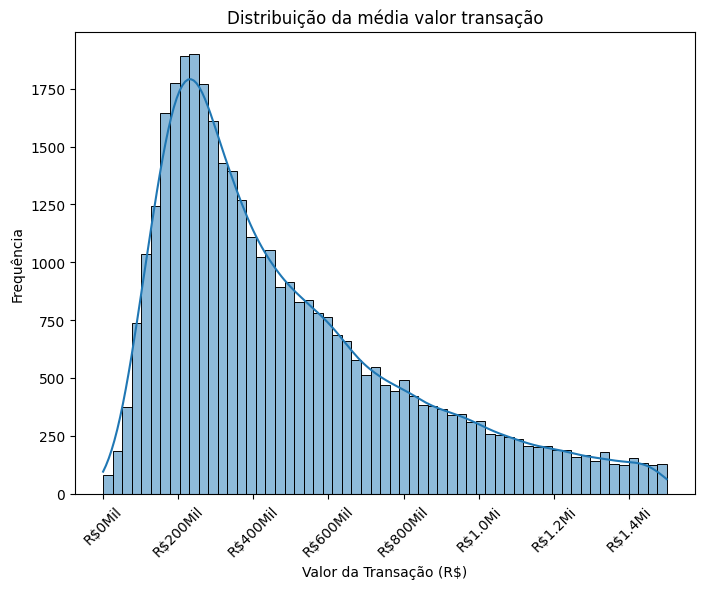

In [40]:
# Visualização da distribuição após a a filtragem do datasaset
plt.figure(figsize=(8, 6))
sns.histplot(df_residencial_filtrado['média_valor_transação'], kde=True)
plt.title('Distribuição da média valor transação')


# Ajustando a escala de ambos os eixos X para formato de moeda
ax = plt.gca()
ax.set_xlabel('Valor da Transação (R$)')
ax.set_ylabel('Frequência')

# Formata os números para "M" (Milhões) ou "K" (Milhares) com ponto
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'R${x/1e6:.1f}Mi' if x >= 1e6 else f'R${x/1e3:.0f}Mil'))
plt.xticks(rotation=45)


plt.show()

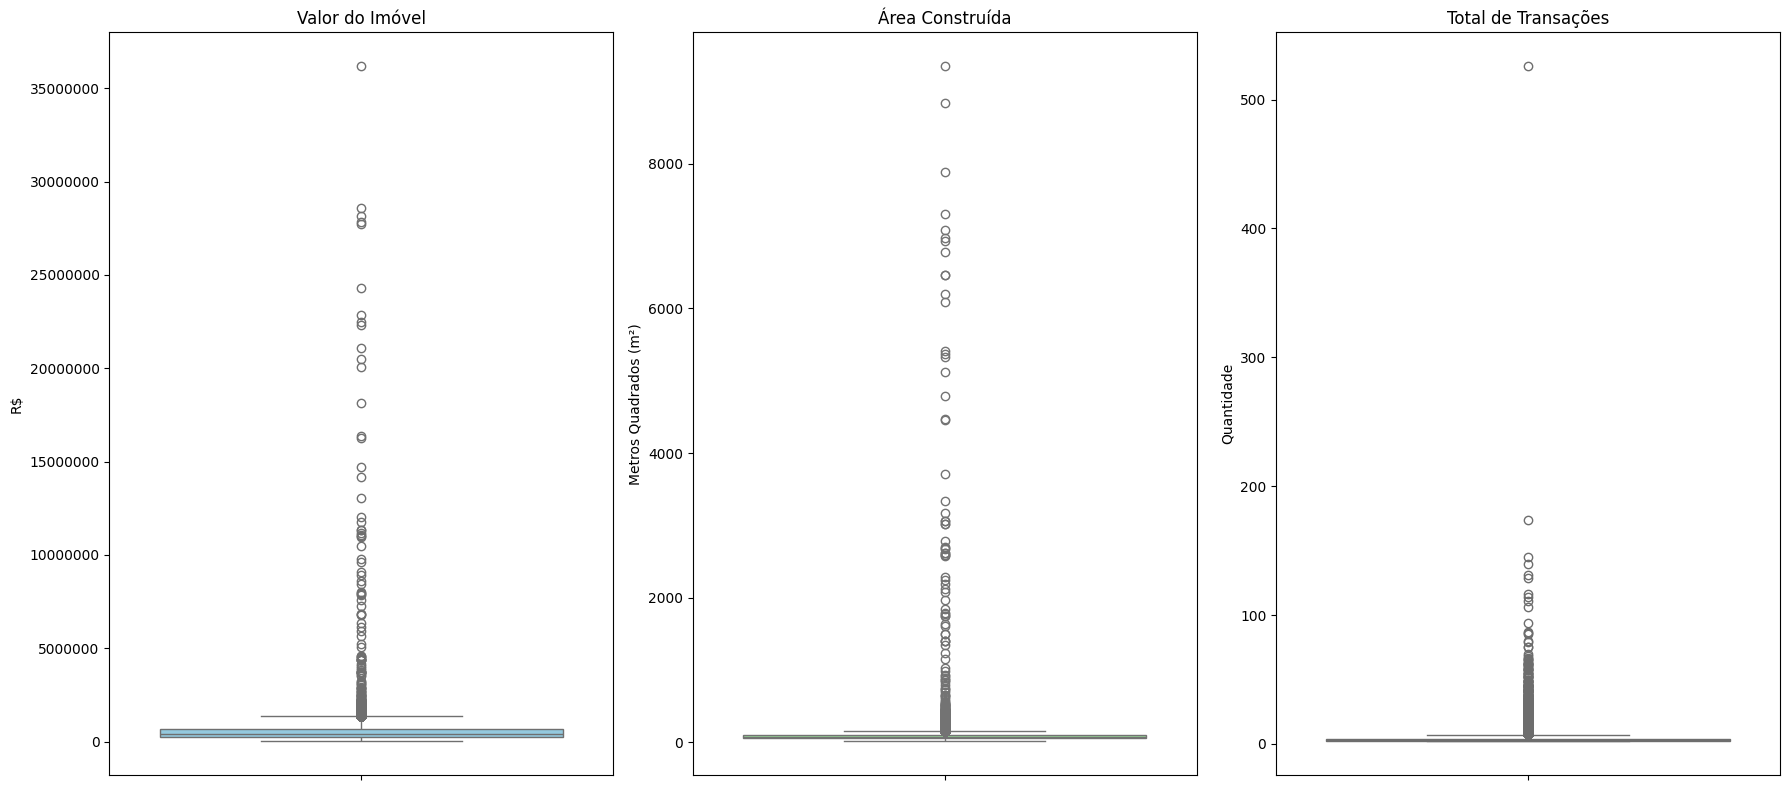

In [41]:
#criando boxplot após a a filtragem do datasaset
fig, axes = plt.subplots(1, 3, figsize=(18, 8))

# 1. Boxplot: média_valor_imóvel
sns.boxplot(y=df_residencial_filtrado['média_valor_imóvel'], ax=axes[0], color='skyblue')
axes[0].set_title('Valor do Imóvel')
axes[0].set_ylabel('R$')
# Formatação para evitar o 1e7
formatter = ScalarFormatter()
formatter.set_scientific(False)
axes[0].yaxis.set_major_formatter(formatter)

# 2. Boxplot: média_área_construída
sns.boxplot(y=df_residencial_filtrado['média_área_construída'], ax=axes[1], color='lightgreen')
axes[1].set_title('Área Construída')
axes[1].set_ylabel('Metros Quadrados (m²)')

# 3. Boxplot: total_transações
sns.boxplot(y=df_residencial_filtrado['total_transações'], ax=axes[2], color='salmon')
axes[2].set_title('Total de Transações')
axes[2].set_ylabel('Quantidade')

# Ajusta o espaçamento entre os gráficos
plt.tight_layout()
plt.show()

Refazendo a estatística descritiva básica e a distribuição dos dados com o dataset filtrado, é possível veríficar que o valor máximo da coluna **média_valor_transação** é **1,499,850.00**, o que tem destoa muito do valor máximo da coluna **média_valor_imóvel**, 36,188,694.48. Da mesma forma que o valor mínimo para ambas as coluas também é muito discrepante sendo respectivamente **432.07 e 12,901.61**.

Além disso, o desvio-padrão para ambas as colunas é continua com um valor bem alto, **330,583.54** e **651,787.01**, respectivamente, fato que também é o observado no histograma, onde ainda observarmos uma distribuição assimétrica à direita e podemos ver que a moda está entre **200 mil e 300 mil**, enquanto a cauda longa na direita.

Outros valores máximos muito grandes identificados é a **'média_área_construída'** de **9,347.00** m2 e o **'total_transações'** com valor de **526.00**.

Devido a essas discrepâncias será realizada o tratamento dos outilers.

## Tratando os Outliers

In [42]:
# Lista das colunas que precisam de tratamento
colunas_outliers = ['média_valor_imóvel', 'média_área_construída', 'total_transações']

# Criamos uma cópia para começar a limpeza
df_limpo = df_residencial_filtrado.copy()

print(f"Registros iniciais: {len(df_limpo)}")
print("-" * 30)

for coluna in colunas_outliers:
    # 1. Calcular os Quartis
    Q1 = df_limpo[coluna].quantile(0.25)
    Q3 = df_limpo[coluna].quantile(0.75)
    IQR = Q3 - Q1

    # 2. Definir os limites
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR

    # 3. Aplicar o filtro na coluna atual
    linhas_antes = len(df_limpo)
    df_limpo = df_limpo[(df_limpo[coluna] >= limite_inferior) & (df_limpo[coluna] <= limite_superior)]
    linhas_removidas = linhas_antes - len(df_limpo)

    print(f"Coluna: {coluna}")
    print(f"  > Limite superior: {limite_superior:.2f}")
    print(f"  > Linhas removidas nesta etapa: {linhas_removidas}")

print("-" * 30)
print(f"Total de registros após limpeza: {len(df_limpo)}")
print(f"Total geral de linhas removidas: {len(df_residencial_filtrado) - len(df_limpo)}")

Registros iniciais: 37281
------------------------------
Coluna: média_valor_imóvel
  > Limite superior: 1371121.69
  > Linhas removidas nesta etapa: 1051
Coluna: média_área_construída
  > Limite superior: 148.25
  > Linhas removidas nesta etapa: 1642
Coluna: total_transações
  > Limite superior: 7.00
  > Linhas removidas nesta etapa: 3684
------------------------------
Total de registros após limpeza: 30904
Total geral de linhas removidas: 6377


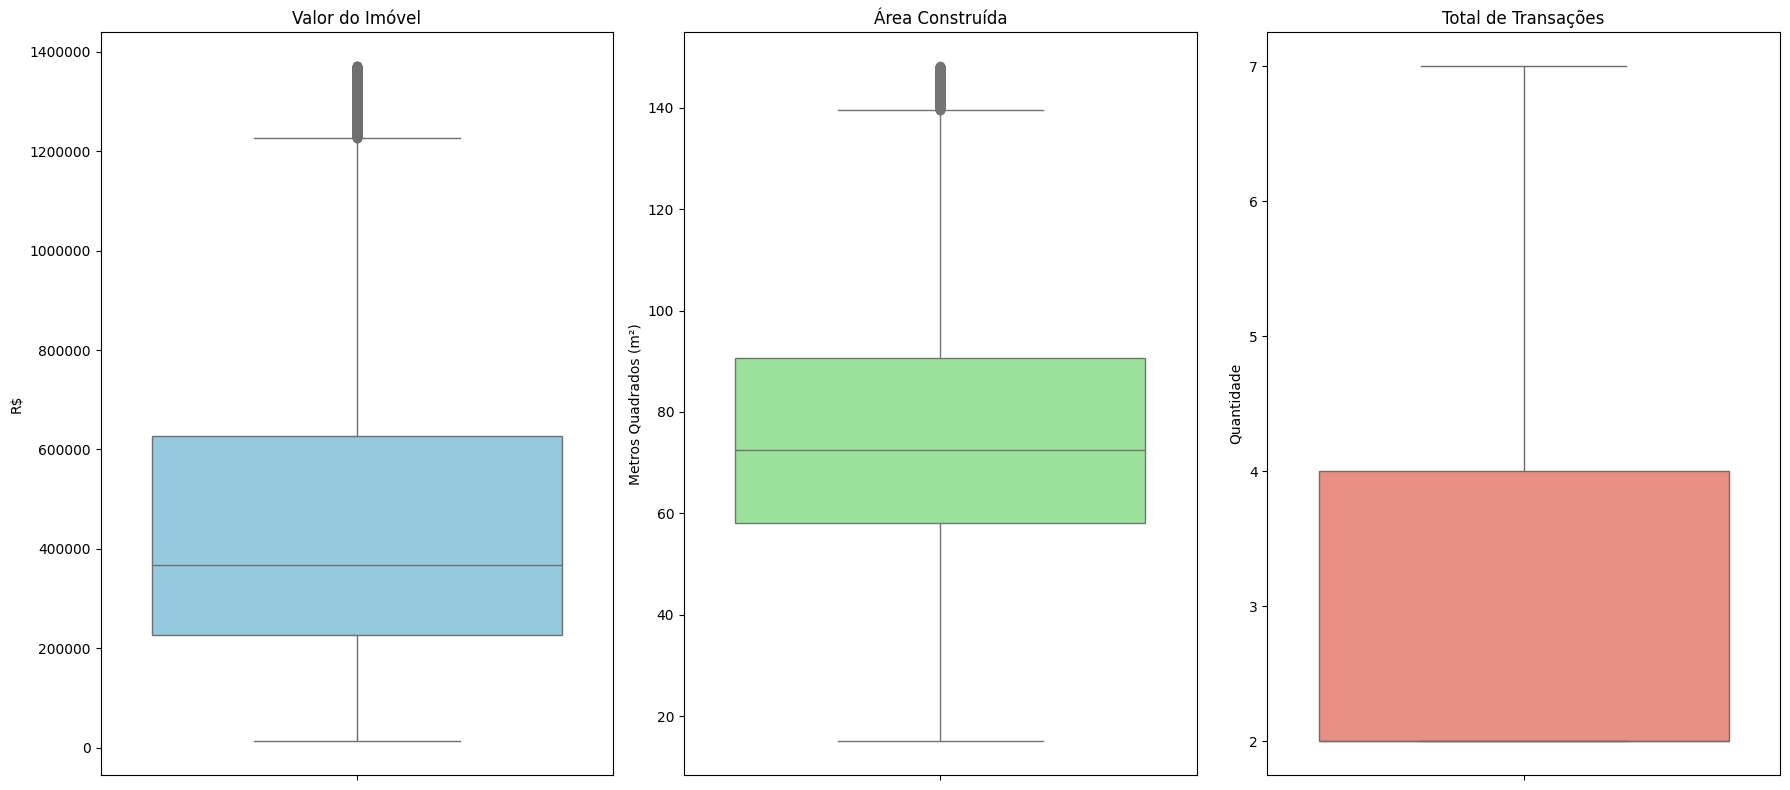

In [43]:
#criando boxplot após a a filtragem do datasaset
fig, axes = plt.subplots(1, 3, figsize=(18, 8))

# 1. Boxplot: média_valor_imóvel
sns.boxplot(y=df_limpo['média_valor_imóvel'], ax=axes[0], color='skyblue')
axes[0].set_title('Valor do Imóvel')
axes[0].set_ylabel('R$')
# Formatação para evitar o 1e7
formatter = ScalarFormatter()
formatter.set_scientific(False)
axes[0].yaxis.set_major_formatter(formatter)

# 2. Boxplot: média_área_construída
sns.boxplot(y=df_limpo['média_área_construída'], ax=axes[1], color='lightgreen')
axes[1].set_title('Área Construída')
axes[1].set_ylabel('Metros Quadrados (m²)')

# 3. Boxplot: total_transações
sns.boxplot(y=df_limpo['total_transações'], ax=axes[2], color='salmon')
axes[2].set_title('Total de Transações')
axes[2].set_ylabel('Quantidade')

# Ajusta o espaçamento entre os gráficos
plt.tight_layout()
plt.show()

In [44]:
with pd.option_context("float_format", "{:,.2f}".format, "display.max_columns", 20):
    display(df_limpo.describe())

,total_transações,média_percentual_transferido,média_área_construída,média_valor_transação,média_valor_imóvel,ano_transação,mês_transação,valor_total_mercado,preco_m2_mercado,preco_m2_avaliado
count,"30,904.00","30,904.00","30,904.00","30,904.00","30,904.00","30,904.00","30,904.00","30,904.00","30,904.00","30,904.00"
mean,3.04,97.03,76.00,"443,413.67","457,832.10","2,022.37",6.46,"457,589.99","5,843.86","457,832.10"
std,1.38,9.79,24.87,"292,588.54","299,392.43",2.09,3.45,"299,855.61","3,040.60","299,392.43"
min,2.00,1.00,15.00,432.07,"12,901.61","2,019.00",1.00,"12,901.61",551.07,"12,901.61"
25%,2.00,100.00,58.00,"220,253.89","226,547.84","2,021.00",3.00,"226,479.24","3,698.96","226,547.84"
50%,2.00,100.00,72.50,"357,007.01","368,141.45","2,022.00",7.00,"367,780.78","5,065.48","368,141.45"
75%,4.00,100.00,90.67,"605,025.34","626,683.26","2,024.00",9.00,"625,248.64","7,714.19","626,683.26"
max,7.00,100.00,148.25,"1,371,020.98","1,371,020.98","2,026.00",12.00,"1,609,083.45","34,674.04","1,371,020.98"


Conforme podemos observar, agora temos um dataset mais homogênio com valores máximos realista. A remoção dos dados reduziu o desvio padrão, preparando o dataset para um modelo de regressão com mais precisão.

## Enconding: Transformando as colunas categóricas em números

In [45]:
# Transforma colunas categóricas em colunas de 0 e 1
# Vamos focar em 'bairro' e 'uso'
df_final = pd.get_dummies(df_limpo, columns=['bairro', 'uso'], drop_first=True)

# Remove colunas de texto que não servem para cálculo matemático
df_final = df_final.drop(columns=['logradouro', 'principais_tipologias', 'principal_transação_mercado'])

In [46]:
df_final.columns

Index(['total_transações', 'média_percentual_transferido',
       'média_área_construída', 'média_valor_transação', 'média_valor_imóvel',
       'ano_transação', 'mês_transação', 'valor_total_mercado',
       'preco_m2_mercado', 'preco_m2_avaliado',
       ...
       'bairro_Vicente de Carvalho', 'bairro_Vidigal', 'bairro_Vigário Geral',
       'bairro_Vila Isabel', 'bairro_Vila Kosmos', 'bairro_Vila Valqueire',
       'bairro_Vila da Penha', 'bairro_Vista Alegre', 'bairro_Zumbi',
       'bairro_Água Santa'],
      dtype='object', length=162)

Além de transformar os dados variáveis categóricas (como bairro e uso) em variáveis binárias,  o get_dummies transformou as linhas em colunas e agora o dataset possui 162 colunas.


#### Separando o dataset em features e target

In [47]:
# Separar features (X) e target (y)
X = df_final.drop(columns=['média_valor_imóvel']) #vai ser usado para aprender
y = df_final['média_valor_imóvel'] # target

#### Separando o dataset em conjuntos de treino e teste

In [48]:
# Dividir os dados em conjuntos de treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [49]:
print(f"Dimensões de X_train: {X_train.shape}")
print(f"Dimensões de X_test: {X_test.shape}")
print(f"Dimensões de y_train: {y_train.shape}")
print(f"Dimensões de y_test: {y_test.shape}")

Dimensões de X_train: (21632, 161)
Dimensões de X_test: (9272, 161)
Dimensões de y_train: (21632,)
Dimensões de y_test: (9272,)


## Normalização

A normalização escala os dados para um intervalo fixo, geralmente entre 0 e 1. É útil quando o algoritmo de machine learning assume que as características estão em uma escala semelhante.



In [50]:
# Inicializar o MinMaxScaler
scaler_norm = MinMaxScaler()

In [51]:
# Aprende min e max APENAS de X_train
scaler_norm.fit(X_train)
X_train_normalized = scaler_norm.transform(X_train)
# Usa a média e o desvio padrão aprendidos de X_train
X_test_normalized = scaler_norm.transform(X_test)

In [52]:
# Exibir as primeiras linhas dos dados normalizados (como DataFrame para melhor visualização)
df_normalized = pd.DataFrame(X_train_normalized, columns=X_train.columns)

In [53]:
print("\nPrimeiras 5 linhas dos dados normalizados (treino):")
print(df_normalized.head())


Primeiras 5 linhas dos dados normalizados (treino):
   total_transações  média_percentual_transferido  média_área_construída  \
0               0.2                           1.0               0.438563   
1               0.2                           1.0               0.491493   
2               0.0                           1.0               0.321361   
3               0.4                           1.0               0.181474   
4               0.0                           1.0               0.415879   

   média_valor_transação  ano_transação  mês_transação  valor_total_mercado  \
0               0.286192       0.571429       0.363636             0.237859   
1               0.361868       0.714286       0.363636             0.302821   
2               0.170386       0.285714       0.090909             0.138450   
3               0.074901       0.857143       0.909091             0.056484   
4               0.307949       0.714286       0.545455             0.256536   

   preco_m2_mer

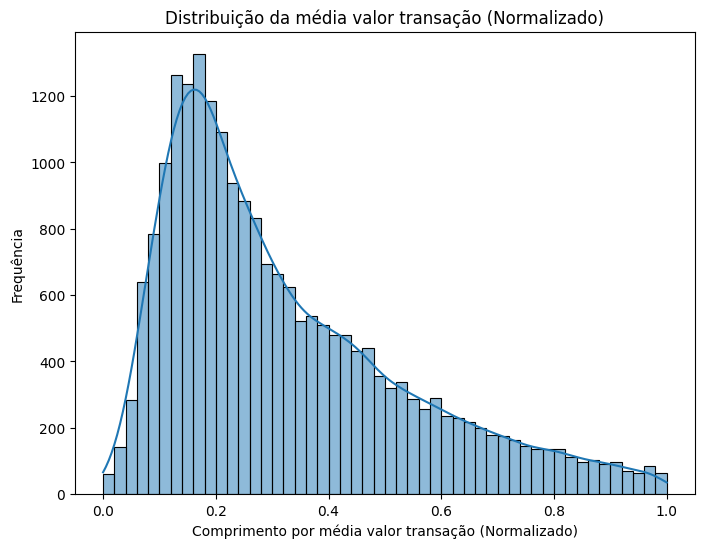

In [54]:
# Visualização da distribuição após a normalização (exemplo para uma característica)
plt.figure(figsize=(8, 6))
sns.histplot(df_normalized['média_valor_transação'], kde=True)
plt.title('Distribuição da média valor transação (Normalizado)')
plt.xlabel('Comprimento por média valor transação (Normalizado)')
plt.ylabel('Frequência')
plt.show()

O histograma de  média_valor_transação após a normalização mostra que os valores foram escalados para o intervalo de 0 a 1, mantendo a forma da distribuição original.

## Padronização

A padronização (ou Z-score scaling) transforma os dados para ter média 0 e desvio padrão 1. É útil para algoritmos que são sensíveis à escala das características, como SVMs ou redes neurais.

In [55]:
# Inicializar o StandardScaler
scaler_std = StandardScaler()

In [56]:
# Aprende média e desvio padrão APENAS de X_train
scaler_std.fit(X_train)
X_train_standardized = scaler_std.transform(X_train)
# Usa a média e o desvio padrão aprendidos de X_train
X_test_standardized = scaler_std.transform(X_test)

In [57]:
# Exibir as primeiras linhas dos dados padronizados (como DataFrame para melhor visualização)
df_standardized = pd.DataFrame(X_train_standardized, columns=X_train.columns)

In [58]:
print("\nPrimeiras 5 linhas dos dados padronizados (treino):")
print(df_standardized.head())


Primeiras 5 linhas dos dados padronizados (treino):
   total_transações  média_percentual_transferido  média_área_construída  \
0         -0.038033                      0.303775              -0.078790   
1         -0.038033                      0.303775               0.202296   
2         -0.758471                      0.303775              -0.701193   
3          0.682404                      0.303775              -1.444062   
4         -0.758471                      0.303775              -0.199255   

   média_valor_transação  ano_transação  mês_transação  valor_total_mercado  \
0              -0.173356       0.298116      -0.423863            -0.215752   
1               0.179371       0.777940      -0.423863             0.129071   
2              -0.713129      -0.661533      -1.291703            -0.743429   
3              -1.158186       1.257764       1.311816            -1.178513   
4              -0.071945       0.777940       0.154696            -0.116613   

   preco_m2_mer

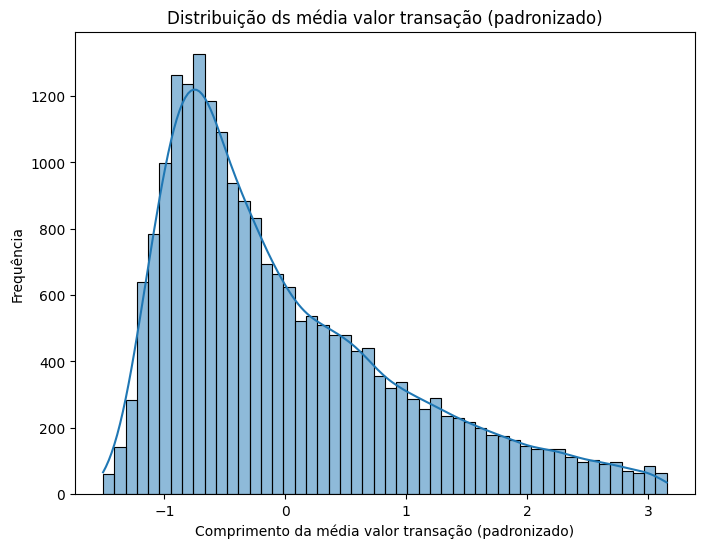

In [59]:
# Visualização da distribuição após a padronização (exemplo para uma característica)
plt.figure(figsize=(8, 6))
sns.histplot(df_standardized['média_valor_transação'], kde=True)
plt.title('Distribuição ds média valor transação (padronizado)')
plt.xlabel('Comprimento da média valor transação (padronizado)')
plt.ylabel('Frequência')
plt.show()

O histograma de **média valor transação** após a padronização mostra que os valores foram transformados para ter uma média próxima de zero e um desvio padrão de um, centralizando a distribuição.

## Outras Transformações e Etapas de Pré-Processamento



#### Matriz de correlação com o dataset limpo

In [60]:
# Matriz de correlação
print("\nMatriz de Correlação:")
correlacao = df_limpo.drop(columns = ['ano_transação','mês_transação','valor_total_mercado','preco_m2_mercado','média_percentual_transferido','preco_m2_avaliado']).corr(numeric_only=True)

display(matriz_correlacao)


Matriz de Correlação:


,total_transações,média_área_construída,média_valor_transação,média_valor_imóvel
total_transações,1.000000,-0.019168,-0.010755,-0.005652
média_área_construída,-0.019168,1.000000,0.139222,0.153879
média_valor_transação,-0.010755,0.139222,1.000000,0.161939
média_valor_imóvel,-0.005652,0.153879,0.161939,1.000000


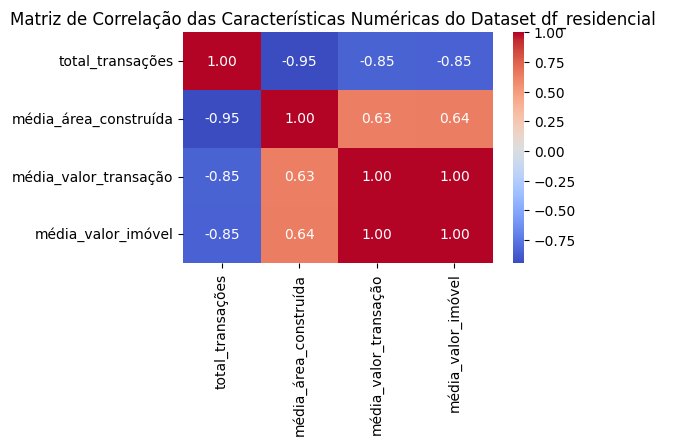

In [61]:
plt.figure(figsize=(5, 3))
# mapa de calor das variáveis numéricas
sns.heatmap(correlacao.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriz de Correlação das Características Numéricas do Dataset df_residencial  ')
plt.show()

O primeiro ponto de atenção é a correlação perfeita **(1.00)** entre o valor de transação e o valor venal indica que, na média, a base tributária da prefeitura acompanha o mercado.

Há  uma influência clara do tamanho do imóvel no preço, mas ela não é a única, uma vez que o coeficiente é **0.63**. A matriz indica que a localização e a tipologia são importantes também.

Outro fator observado é que o volume de transação é inversamente **(-0.85)** proporcional ao valor dos imóveis.

# Respondendo nossas hipóteses

Quais visualizações, tabelas e células descritivas respondem às hipóteses que você levantou?



In [62]:
df_limpo.head()

,logradouro,bairro,total_transações,uso,principais_tipologias,média_percentual_transferido,média_área_construída,média_valor_transação,média_valor_imóvel,principal_transação_mercado,ano_transação,mês_transação,valor_total_mercado,preco_m2_mercado,preco_m2_avaliado
54337,AVN GOMES FREIRE,Centro,2,RESIDENCIAL,APARTAMENTO,100.0,30.50,228790.4400,228790.4400,COMPRA E VENDA,2019,7,228790.440000,7501.325902,228790.4400
54338,AVN GOMES FREIRE,Centro,3,RESIDENCIAL,APARTAMENTO,100.0,32.00,209717.8300,209717.8300,COMPRA E VENDA,2019,10,209717.830000,6553.682187,209717.8300
54339,RUA DOS INVALIDOS,Centro,4,RESIDENCIAL,APARTAMENTO,100.0,49.25,309725.5325,309725.5325,COMPRA E VENDA,2019,5,309725.532500,6288.843299,309725.5325
54401,RUA DA LAPA,Centro,2,RESIDENCIAL,APARTAMENTO,100.0,46.00,371079.1300,371079.1300,COMPRA E VENDA,2019,2,371079.130000,8066.937609,371079.1300
54402,AVN MEM DE SA,Centro,2,RESIDENCIAL,APARTAMENTO,65.0,49.00,129680.4550,232759.7850,COMPRA E VENDA,2019,5,199508.392308,4071.599843,232759.7850


## Hipótese 1 : Bairros com maior volume de transações aumentam o valor médio da transação no ano seguinte?

In [63]:
# 1. agupando as colunas de interesse, somando o total de transações e calculando a média da média_valor_transação
# Os dados de 2026 vão ser usados para avaliar tendências de volume total, pois o ano ainda está em curso
analise_temporal = df_limpo[df_limpo['ano_transação'] != 2026].groupby(['ano_transação', 'bairro']).agg({
    'total_transações': 'sum',
    'média_valor_transação': 'mean'
}).reset_index()

# 2. Ordenando pelo ano e pelo volume de transações
analise_temporal = analise_temporal.sort_values(['ano_transação', 'total_transações'], ascending=[True, False])

# 3. Pegando os 3 primeiros de cada grupo (ano)
top_3_por_ano = analise_temporal.groupby('ano_transação').head(3)


In [64]:
with pd.option_context("float_format", "{:,.2f}".format, "display.max_columns", 4):
    display(top_3_por_ano)


,ano_transação,bairro,total_transações,média_valor_transação
31,2019,Copacabana,870,"703,371.19"
7,2019,Barra da Tijuca,785,"746,821.89"
92,2019,Recreio dos Bandeirantes,725,"549,800.43"
156,2020,Copacabana,873,"708,142.45"
133,2020,Barra da Tijuca,815,"768,691.49"
222,2020,Recreio dos Bandeirantes,806,"550,140.98"
290,2021,Copacabana,1139,"674,008.31"
363,2021,Recreio dos Bandeirantes,1137,"549,863.11"
267,2021,Barra da Tijuca,1012,"751,418.80"
428,2022,Copacabana,1126,"694,069.80"


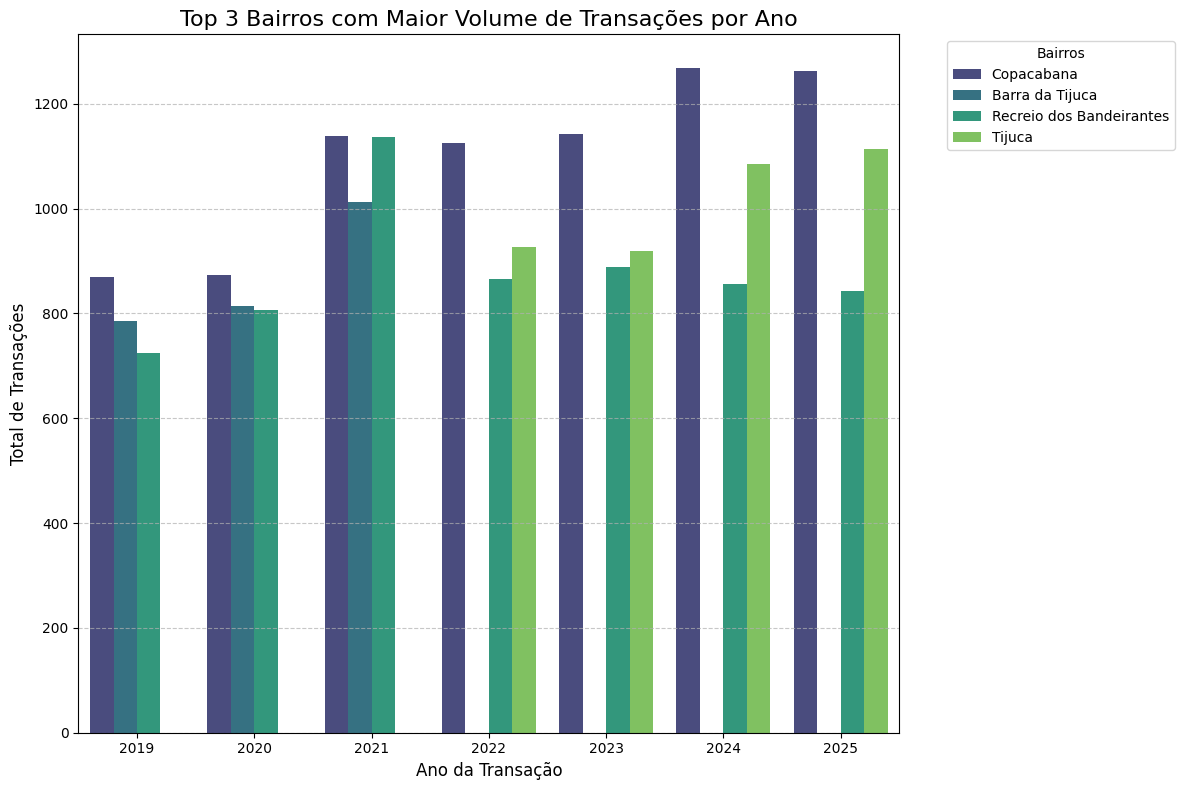

In [65]:
#Preparando os dados (garantindo que estão ordenados)
df_plot = top_3_por_ano.copy()

#Criando o gráfico
plt.figure(figsize=(12, 8))
sns.barplot(
    data=df_plot,
    x='ano_transação',
    y='total_transações',
    hue='bairro',
    palette='viridis'
)

#justando detalhes visuais
plt.title('Top 3 Bairros com Maior Volume de Transações por Ano', fontsize=16)
plt.xlabel('Ano da Transação', fontsize=12)
plt.ylabel('Total de Transações', fontsize=12)
plt.legend(title='Bairros', bbox_to_anchor=(1.05, 1), loc='upper left') # Move a legenda para fora
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

Como podemos ver nas análises acimam Copacabana é o bairro com a maior quantidade de transações entre todos os anos analisados. A barra da tijuca era o segundo colocado até 2021 e o Recreio dos Bandeirantes foi tereceiro colocado em todos os anos. Já a partir de 2022 a Tijuca ultrapassou a Barra da tijuca e passou a ser a segunda colocada.

In [66]:
#criando a coluna para fazer a análise temporal
analise_temporal['preco_ano_seguinte'] = analise_temporal.groupby('bairro')['média_valor_transação'].shift(-1)

# Remover linhas que não possuem o ano seguinte (o último ano do dataset)
analise_temporal.dropna(subset=['preco_ano_seguinte'], inplace=True)

In [67]:
# criando uma matriz de correlação para analisar a relação entre as variáveis 'total_transações' e 'preco_ano_seguinte'
correlacao_hipotese = analise_temporal[['total_transações', 'preco_ano_seguinte']].corr()
print(correlacao_hipotese)

                    total_transações  preco_ano_seguinte
total_transações            1.000000            0.391952
preco_ano_seguinte          0.391952            1.000000


Como é possível observar na matriz de correlação, o volume de vendas não determina o preço do ano seguinte, uma vez que a correlação entre essas variáveis é fraca **(0.389004).**

## Hipótese 2: Em quais bairrros há maior discrepância entre o valor médio da trasação e o valor médio do imóvel?



In [68]:
#acrescentando a coluna diferenção valor_real_vs_iptu que compara oo valor de venda com o valor do imóvel com base no iptu
df_limpo['diferenca_real_vs_iptu'] = df_limpo['média_valor_transação'] - df_limpo['média_valor_imóvel']

#agrupando o dataset por bairro e retornando a média_valor_transação e média_valor_imóvel
valor_médio_da_transação_vs_imovel = df_limpo.groupby('bairro').agg({
    'média_valor_transação': 'mean',
    'média_valor_imóvel': 'mean',
    'diferenca_real_vs_iptu': 'mean'
}).sort_values(by='diferenca_real_vs_iptu', ascending = True)


with pd.option_context("float_format", "{:,.2f}".format, "display.max_columns", 4):
    display(valor_médio_da_transação_vs_imovel.head())




,média_valor_transação,média_valor_imóvel,diferenca_real_vs_iptu
bairro,,,
Urca,"797,687.50","921,549.35","-123,861.85"
Cosme Velho,"847,821.97","928,684.65","-80,862.68"
Lagoa,"1,118,314.00","1,175,780.04","-57,466.04"
Alto da Boa Vista,"401,625.92","456,880.56","-55,254.64"
Leblon,"1,045,879.35","1,093,659.11","-47,779.76"


In [69]:
#agrupando o dataset por bairro e retornando a média_valor_transação e média_valor_imóvel
valor_médio_da_transação_vs_imovel = df_limpo.groupby('bairro').agg({
    'média_valor_transação': 'mean',
    'média_valor_imóvel': 'mean',
    'diferenca_real_vs_iptu': 'mean'
}).sort_values(by='diferenca_real_vs_iptu', ascending = False)


with pd.option_context("float_format", "{:,.2f}".format, "display.max_columns", 4):
    display(valor_médio_da_transação_vs_imovel.head())




,média_valor_transação,média_valor_imóvel,diferenca_real_vs_iptu
bairro,,,
Acari,"36,051.46","36,051.46",0.00
Campo dos Afonsos,"190,796.45","190,796.45",0.00
Barros Filho,"105,288.02","105,288.02",0.00
Jabour,"133,991.92","133,991.92",0.00
Gamboa,"175,515.40","175,515.40",0.00


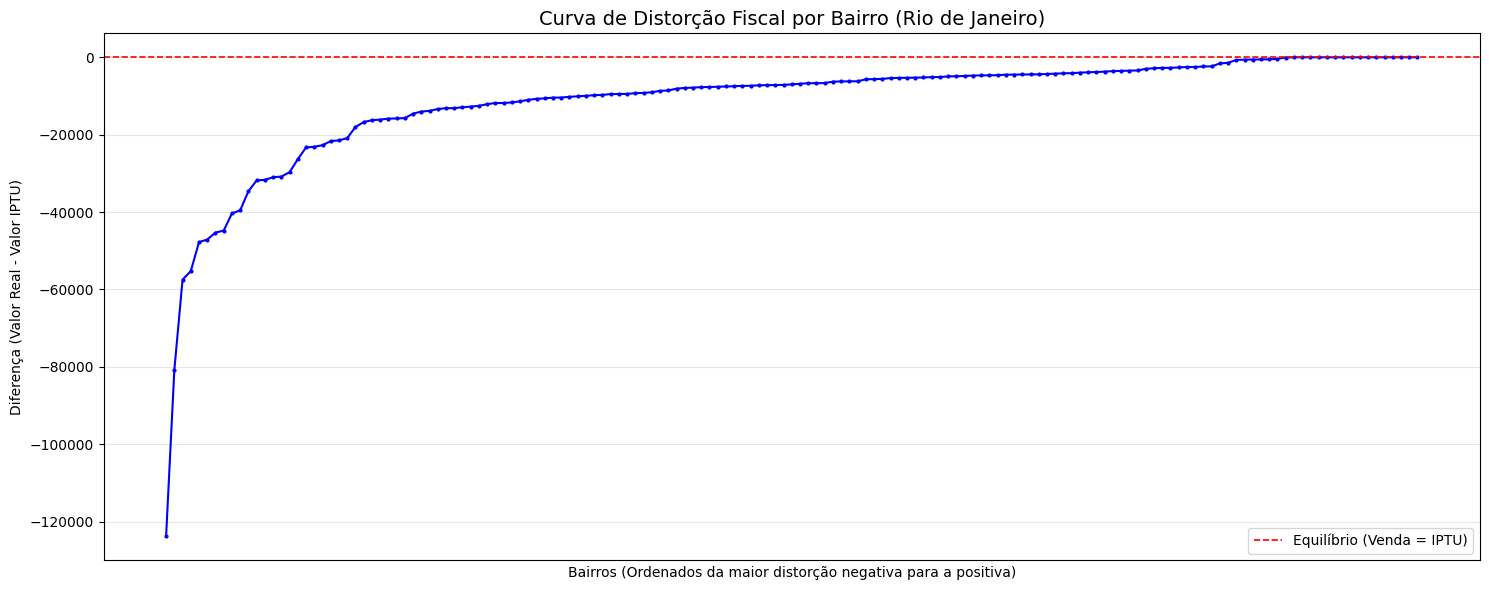

In [70]:
# 1. Preparar os dados (ordenando todos os bairros pela diferença)
df_linha = valor_médio_da_transação_vs_imovel.sort_values(by='diferenca_real_vs_iptu').reset_index()

# 2. Criar o gráfico de linha
plt.figure(figsize=(15, 6))
plt.plot(df_linha['bairro'], df_linha['diferenca_real_vs_iptu'], marker='o', markersize=2, linestyle='-', color='blue')

# 3. Adicionar linha de referência no Zero
plt.axhline(0, color='red', linestyle='--', linewidth=1.2, label='Equilíbrio (Venda = IPTU)')

# 4. Estética
plt.title('Curva de Distorção Fiscal por Bairro (Rio de Janeiro)', fontsize=14)
plt.ylabel('Diferença (Valor Real - Valor IPTU)')
plt.xlabel('Bairros (Ordenados da maior distorção negativa para a positiva)')

# Como são muitos bairros, vamos esconder os nomes no eixo X para não virar um borrão,
# mas manter os ticks para dar a noção de volume.
plt.xticks([])

plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

Como é possível observar as nas tabelas e gráficos acima, ao filtrarmos o dataset pelas maiores distorções distorções de **valor de transação** e **valor de avaliação do imóvel**, temos que esses valores são zeros. Já quando analisamos o oposto vemos que esse valor é muito negativo, chegando a diferença negativa de **-123,861.85** na **Urca**.

Outro ponto importante é que os bairros com valor do imóvel alto que sofrem mais em conseguir transacionar dentro do valor avaliado pela prefeitura, assim os proprietários pagam um imposto caro, mas não recebem a recompensa na hora da venda.

Por outro lado, os imóveis que tem diferença zero são imóveis mais baratos em bairros não valorizados, onde valor de mercado reflete o valor de avaliação da prefeitura.

Essa análise permitiu perceber que análise de correlação feita anteriormente não estava precisa ao trazer uma correlação perfeita entre o valor de transação e o valor venal. Isso ocorreu devido a distorções graves em bairros de luxo csobrevalorização fiscal).

## Hipótese 3: A sazonalidade afeta o volume de vendas na cidade de uma maneira geral?


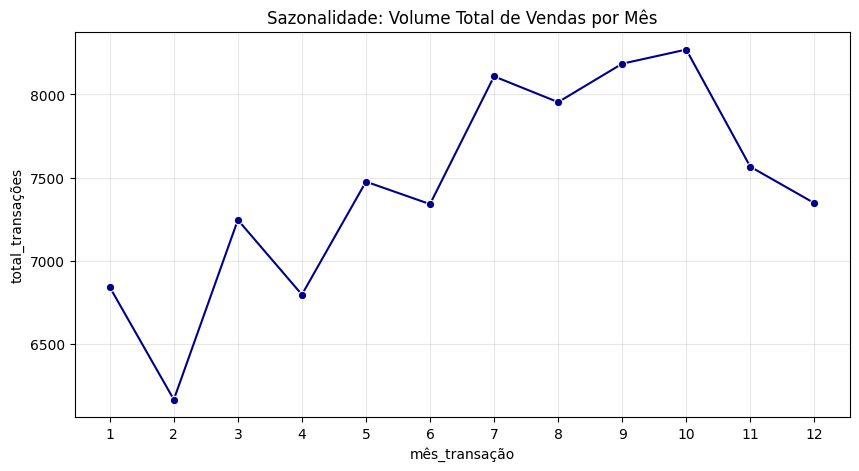

In [71]:
# 1. Agrupando por mês para ver o comportamento médio da cidade
sazonalidade = df_limpo[df_limpo['ano_transação'] != 2026].groupby('mês_transação').agg({'total_transações': 'sum'})

#como é uma analise temporal, removi o ano atual que ainda está imcompleto
# 2. Criando um gráfico de linha para visualizar o comportamento ao longo dos meses

plt.figure(figsize=(10, 5))
sns.lineplot(data=sazonalidade, x='mês_transação', y='total_transações', marker='o', color='darkblue')

plt.title('Sazonalidade: Volume Total de Vendas por Mês')
plt.xticks(range(1, 13)) # Garante que apareçam todos os meses de 1 a 12
plt.grid(alpha=0.3)
plt.show()

Os comportamento do volume de vendas está em acordo com eventos que ocorrem no Brasil e no Rio de Janeiro. O Volume de vendas é baixo no inicio do ano e o possível motivo é devido ao pagamento de impostos como o IPVA e IPTU, além do Carnaval e férias de algumas pessoas.

Em março há um pico relevante e pode ser explicado pelo período de pagamento de bônus e PLRs nessa época do ano. Além de uma demanda reprimida do início do ano.

Já no segundo semestre, o volume de vendas sobre consistentemente de junho a outubro. Já em novembro, o volume volta a cair devido a preparação para o fim do ano.

## Hipótese 4: Há diferença entre o preço do metro quadrado entre imóveis de tipologia?

In [72]:
# 2. Filtrar uma região específica com muitos dados e comparar as tipologias
# Troque 'Barra da Tijuca' por um bairro que você sabe que tem casa e apto
analise_tipologia = df_limpo.groupby('principais_tipologias').agg({
    'preco_m2_mercado': 'mean',
    'principais_tipologias': 'count'
}).sort_values(by='preco_m2_mercado', ascending=False)

display(analise_tipologia)

,preco_m2_mercado,principais_tipologias
principais_tipologias,,
APARTAMENTO,6164.317085,28342
APARTAMENTO (PROLETARIO),3322.510015,4
CASA,2302.529054,2540
CASA/APTO (PROLETARIO),1556.389605,18


Analisando as tipologias, é possíve notar que a área do imóvel não é suficiente para determinar o preço do metro quadrado e que a tipologia do imóvel também importa.
Como podemos observar, metro quadrado de um Apartamento (6.164 reais) é quase o triplo de uma Casa (2.302 reais) na média da cidade.

Além disso, há uma queda no valor quando passamos para o padrão Proletário. No entanto, temos uma quantidade menor dessas tipologias.

# Conclusão

A análise e o pré-processamento dos dados de transações imobiliárias demonstraram a importância de tratar e filtrar o dataset antes de qualquer interpretação. O conjunto de dados original apresentava ruídos, como imóveis comerciais e registros com áreas irreais, que foram saneados para permitir uma análise focada no mercado residencial. A exploração revelou correlações claras entre a área construída e o valor de mercado, além de expor distorções fiscais em bairros de alto padrão. As etapas de limpeza e categorização por tipologia foram fundamentais para entender que o mercado não é homogêneo, garantindo que as conclusões reflitam a realidade das transações na cidade.

A partir da análise realizada, as hipóteses levantadas foram validadas:
1. **Bairros com maior volume de transações aumentam o valor médio da transação no ano seguinte?** Não, os dados mostraram que a correlação entre o aumento do volume de vendas e o aumento do preço do imóvel no ano seguinte é baixa.
2. **Em quais bairrros há maior discrepância entre o valor médio da trasação e o valor médio do imóvel?**  Identificamos que, em bairros nobres (como a Urca), existe uma sobrevalorização fiscal, onde o valor de avaliação para imposto é consideravelmente maior que o valor real de venda, diferente do que ocorre em bairros mais populares.
3. **A sazonalidade afeta o volume de vendas na cidade de uma maneira gera?** Sim. Os dados mostraram um ciclo de mercado que começa em baixa no verão e Carnaval, apresenta um pico de recuperação em Março e cresce de forma consistente no segundo semestre, atingindo o ápice em Outubro.
4. **Há diferença entre o preço do metro quadrado entre imóveis de tipologias diferentes?** Sim. O metro quadrado de um apartamento padrão é quase o triplo do valor de uma casa. Além disso, o padrão construtivo (popular/proletário vs. padrão) influencia o preço tanto quanto a localização.